# 03 -  Desarrollo y Evaluación de Modelos

## 1. Descripción General

En este notebook se desarrollará la fase de modelado del proyecto de predicción de precios de Airbnb. El objetivo principal de esta etapa es entrenar, evaluar y comparar distintos modelos de Machine Learning capaces de estimar el precio de una propiedad a partir de las variables seleccionadas durante los procesos de *Data Exploration* y *Feature Engineering*.

A diferencia de las etapas anteriores, donde el enfoque estuvo centrado en la comprensión de los datos, la creación de características y la selección de variables, en esta fase se trabajará sobre un dataset final (`df_model`) que ya ha sido preprocesado, transformado y validado. Esto permite concentrar el análisis exclusivamente en el desempeño de los modelos predictivos.

Para este proyecto se utilizarán tres enfoques de modelado:

- ***Linear Regression***: como modelo baseline de referencia debido a su simplicidad e interpretabilidad.
- ***Random Forest Regressor***: un modelo basado en ensambles de árboles capaz de capturar relaciones no lineales entre las variables.
- ***XGBoost Regressor***: uno de los algoritmos más utilizados en problemas de datos tabulares por su capacidad predictiva y robustez.

El proceso de modelado abarca los pasos necesarios para entrenar, evaluar y seleccionar el mejor modelo:

- División de los datos en conjuntos de entrenamiento, validación y prueba.
- Entrenamiento de los modelos candidatos con hiperparámetros iniciales.
- Evaluación de los modelos utilizando métricas de regresión apropiadas para el problema, incluyendo **R²**, **RMSE** y **MAE**.
- Optimización de hiperparámetros y comparación de resultados para seleccionar el modelo con mejor desempeño.
- Evaluación del modelo ganador sobre datos no vistos para analizar su capacidad de generalización, detectar posibles señales de sobreajuste y validar rendimiento.

Al concluir este notebook se contará con un modelo predictivo final, validado y documentado, capaz de estimar precios de propiedades Airbnb y listo para ser utilizado en futuras etapas de inferencia, despliegue y construcción de servicios de predicción.

## 2. Importación de Librerías y Carga del Dataset

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import shap

# Add project root to path
sys.path.append(os.path.abspath(".."))

# Load the autoreload extension to automatically reload modules when they change
# Set autoreload mode to 2: reload all modules before executing user code
%load_ext autoreload
%autoreload 2

# Import regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# import modules for training, evaluation and final model selection
from src.modeling.data_splitting import split_data
from src.modeling.training import train_model
from src.modeling.evaluation import evaluate_model
from src.modeling.cross_validation import cross_validate_model
from src.modeling.tuning import tune_model

# Import model parameter grids from settings
from src.settings.model_settings import (
    RF_PARAM_GRID,
    XGB_PARAM_GRID
)

# Import feature list from model configuration
from src.settings.model_settings import MODEL_FEATURES

# Model persistence
import joblib
from pathlib import Path
import json
from datetime import datetime

# Load the final modeling dataset generated during the Feature Engineering phase.
df_model = pd.read_csv("../data/processed/df_model.csv")

# Preview first rows
df_model.head()

c:\ML_DS_Learning\airbnb-price-prediction-cdmx\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,dist_to_nearest_attraction,beds,amenity_score,accommodates,bedrooms,bathrooms,attractions_within_radius,commercial_within_radius,...,instant_bookable,has_tv,has_elevator,has_free_parking,has_coffee_maker,has_outdoor_furniture,has_air_conditioning,has_self_check_in,has_pool,log_price
0,1,0,2.450990,1.0,0.268380,2,1.0,1.0,0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,8.208764
1,4,2,0.415358,8.0,1.044497,14,5.0,5.5,4,252,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,9.798127
2,1,0,0.375601,1.0,0.976673,2,1.0,1.0,3,129,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,6.381816
3,5,0,0.985700,10.0,1.261502,16,5.0,5.0,1,53,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,8.208764
4,0,2,1.557305,1.0,1.033924,2,1.0,1.0,0,116,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,5.771441


## 3. División de Datos en Train / Test / Validation

Antes de entrenar los modelos, es necesario dividir el dataset en subconjuntos independientes que permitan desarrollar y evaluar los modelos de forma objetiva.

Para este proyecto se utilizará una estrategia de partición **70% / 15% / 15%**, donde cada conjunto cumple una función específica:

- **Training Set (70%):** utilizado para entrenar los modelos, aprender los patrones presentes en los datos y aplicar validación cruzada.
- **Validation Set (15%):** utilizado para comparar modelos, optimizar hiperparámetros y evaluar su capacidad de generalización durante el desarrollo.
- **Test Set (15%):** reservado exclusivamente para la evaluación final del modelo seleccionado, proporcionando una estimación imparcial de su desempeño sobre datos no vistos.

Esta separación ayudará a prevenir fugas de información (*data leakage*) y permitirá detectar posibles problemas de sobreajuste (*overfitting*) o subajuste (*underfitting*) durante el proceso de modelado.

La variable objetivo utilizada en este proyecto será `log_price`, ya que la transformación logarítmica aplicada durante la etapa de *Feature Engineering* permitió reducir la asimetría de la distribución del precio y mejorar las condiciones para el entrenamiento de modelos de regresión.

============= DATASET SPLITS =============
X_train: (15015, 27)
X_val:   (3217, 27)
X_test:  (3218, 27)

y_train: (15015,)
y_val:   (3217,)
y_test:  (3218,)

============= TARGET DISTRIBUTION =============

              Train   Validation         Test
count  15015.000000  3217.000000  3218.000000
mean       6.975443     6.962141     6.964193
std        0.733728     0.729505     0.731168
min        4.852030     4.844187     4.948760
25%        6.496020     6.486161     6.481577
50%        6.957497     6.941190     6.961296
75%        7.387090     7.377759     7.381346
max       11.812786    11.520010    11.326066


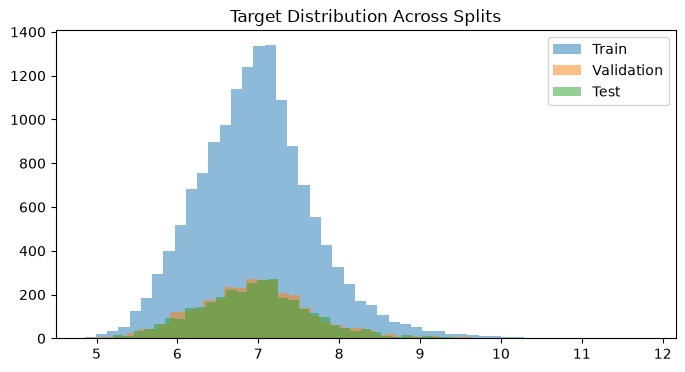

In [2]:
# TRAIN / VALIDATION / TEST SPLIT


# Separate features and target
X = df_model[MODEL_FEATURES]
y = df_model["log_price"]

# Split dataset into training, validation, and test sets
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    X,
    y,
    test_size=0.15,
    validation_size=0.15,
    random_state=42
)

# Validate dataset shapes
print("============= DATASET SPLITS =============")

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print()

print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")
print(f"y_test:  {y_test.shape}")


# Validate target distributions
print("\n============= TARGET DISTRIBUTION =============\n")

# Combine distributions into one table
summary = pd.concat([
    y_train.describe().to_frame(name="Train"),
    y_val.describe().to_frame(name="Validation"),
    y_test.describe().to_frame(name="Test")
], axis=1)

print(summary)

# Visualize distributions
plt.figure(figsize=(8,4))

plt.hist(y_train, bins=50, alpha=0.5, label="Train")
plt.hist(y_val, bins=50, alpha=0.5, label="Validation")
plt.hist(y_test, bins=50, alpha=0.5, label="Test")

plt.legend()
plt.title("Target Distribution Across Splits")

plt.show()

La partición de los datos se realizó exitosamente siguiendo la estrategia definida de **70% entrenamiento, 15% validación y 15% prueba**, obteniendo 15,015 observaciones para entrenamiento, 3,217 para validación y 3,218 para prueba.

Adicionalmente, se verificó la distribución de la variable objetivo (`log_price`) en cada subconjunto. Los estadísticos descriptivos muestran valores muy similares en términos de media, mediana, desviación estándar y percentiles, lo que indica que los tres conjuntos conservan una distribución consistente del precio transformado.

En particular, la media de `log_price` se mantiene cercana a 6.97 en los tres conjuntos, mientras que la desviación estándar permanece alrededor de 0.73. De forma similar, los percentiles 25, 50 y 75 presentan diferencias mínimas entre entrenamiento, validación y prueba.

Estos resultados sugieren que la partición fue adecuada y que no existen diferencias significativas entre los subconjuntos. Como consecuencia, los modelos podrán entrenarse, optimizarse y evaluarse sobre muestras representativas de la misma población, permitiendo una estimación más confiable de su capacidad de generalización.

### Pipeline de preprocesamiento

In [3]:
# PREPROCESSING PIPELINE

# Import preprocessing pipeline
from src.preprocess.preprocess_features import (
    fit_preprocessing_pipeline,
    transform_preprocessing_pipeline
)

# Fit preprocessing components using only training data
preprocessing_pipeline = fit_preprocessing_pipeline(
    X_train
)

# Transform training set
X_train_processed = transform_preprocessing_pipeline(
    X_train,
    preprocessing_pipeline
)

# Transform validation set
X_val_processed = transform_preprocessing_pipeline(
    X_val,
    preprocessing_pipeline
)

# Transform test set
X_test_processed = transform_preprocessing_pipeline(
    X_test,
    preprocessing_pipeline
)

# Display resulting shapes
print("=" * 50)
print("PREPROCESSING COMPLETED")
print("=" * 50)

print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_val_processed:   {X_val_processed.shape}")
print(f"X_test_processed:  {X_test_processed.shape}")

# Check for missing values
print()
print("=" * 50)
print("MISSING VALUES CHECK")
print("=" * 50)

print(f"Train missing values: {X_train_processed.isna().sum().sum()}")
print(f"Validation missing values: {X_val_processed.isna().sum().sum()}")
print(f"Test missing values: {X_test_processed.isna().sum().sum()}")

# Summary statistics of processed training set
pd.set_option("display.max_columns", None)
print()
print("=" * 50)
print("TRAINING DATA SUMMARY STATISTICS")
print("=" * 50)
X_train_processed.describe(include="all")

PREPROCESSING COMPLETED
X_train_processed: (15015, 30)
X_val_processed:   (3217, 30)
X_test_processed:  (3218, 30)

MISSING VALUES CHECK
Train missing values: 0
Validation missing values: 0
Test missing values: 0

TRAINING DATA SUMMARY STATISTICS


,amenity_score,commercial_within_radius,host_is_superhost,instant_bookable,has_tv,has_elevator,has_free_parking,has_coffee_maker,has_outdoor_furniture,has_air_conditioning,has_self_check_in,has_pool,accommodates_log,bathrooms_log,beds_log,bedrooms_log,dist_to_nearest_attraction_log,attractions_within_radius_log,calculated_host_listings_count_entire_homes_log,calculated_host_listings_count_private_rooms_log,minimum_nights_segment_ord,host_verifications_grouped_ord,review_scores_mean_segment_ord,host_total_listings_segment_ord,neighbourhood_cleansed_freq,property_group_room_freq,room_type_entire_home/apt,room_type_hotel_room,room_type_private_room,room_type_shared_room
count,15015.000000,1.501500e+04,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,1.501500e+04,1.501500e+04,15015.000000,1.501500e+04,15015.000000,1.501500e+04,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,1.501500e+04,1.501500e+04,15015.000000,15015.000000,15015.000000,15015.000000
mean,0.499593,8.068434e-17,0.414719,0.458208,0.860473,0.358175,0.304229,0.682118,0.227772,0.093040,0.589344,0.075191,1.798243e-17,-3.757382e-16,0.725259,3.217909e-17,0.242929,1.963871e-17,0.218908,0.591821,0.120346,2.024642,0.757975,1.461871,2.650043e-16,-4.694362e-16,0.685781,0.002597,0.300766,0.010856
std,0.207012,1.000033e+00,0.492690,0.498267,0.346507,0.479480,0.460095,0.465669,0.419409,0.290499,0.491969,0.263709,1.000033e+00,1.000033e+00,0.975208,1.000033e+00,0.805023,1.000033e+00,0.894174,0.885318,0.384315,0.474674,1.035357,1.138121,1.000033e+00,1.000033e+00,0.464220,0.050900,0.458606,0.103628
min,0.000000,-1.220334e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.601855e+00,-3.132214e+00,-1.709511,-2.784440e+00,-0.878577,-1.160175e+00,-0.730423,0.000000,0.000000,0.000000,-1.000000,0.000000,-1.414999e+00,-1.627649e+00,0.000000,0.000000,0.000000,0.000000
25%,0.353136,-8.842348e-01,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.531512e-01,-5.734838e-01,0.000000,-5.654137e-01,-0.339974,-1.160175e+00,-0.269577,0.000000,0.000000,2.000000,0.000000,0.000000,-9.128766e-01,-1.081395e+00,0.000000,0.000000,0.000000,0.000000
50%,0.533257,-2.190389e-01,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.996499e-02,-5.734838e-01,0.000000,-5.654137e-01,0.000000,1.282544e-01,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,-5.845283e-01,7.630026e-01,1.000000,0.000000,0.000000,0.000000
75%,0.657083,6.842272e-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,5.420745e-01,9.232776e-01,1.000000,7.326338e-01,0.660026,9.411631e-01,0.730423,1.000000,0.000000,2.000000,2.000000,2.000000,9.898511e-01,7.630026e-01,1.000000,0.000000,1.000000,0.000000
max,1.000000,2.630801e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.405454e+00,8.106542e+00,7.449284,9.104111e+00,3.826978,1.754072e+00,2.861598,3.892789,2.000000,3.000000,2.000000,3.000000,9.898511e-01,7.630026e-01,1.000000,1.000000,1.000000,1.000000


## 4. Métricas de Evaluación de Estrategia de Validación

Antes de entrenar los modelos, es necesario definir los criterios que se utilizarán para evaluar su desempeño y comparar sus resultados de manera consistente. Dado que el objetivo del proyecto consiste en predecir una variable numérica continua (`log_price`), se utilizarán métricas estándar para problemas de regresión. Cada métrica proporciona una perspectiva diferente sobre la calidad de las predicciones, por lo que se analizarán de forma complementaria.

### Métricas de evaluación

- **R² Score (Coefficient of Determination)**

    El coeficiente de determinación mide la proporción de la variabilidad de la variable objetivo que es explicada por el modelo a partir de las variables predictoras (características).

    Interpretación de los valores de *R²* :

    - **R² = 1.0**: Representa un ajuste perfecto. El modelo explica toda la variabilidad de los datos. Todas las predicciones coinciden exactamente con los valores reales.
    - **R² entre 0.7 y 0.9**: Indica un muy buen ajuste. El modelo es capaz de explicar la gran mayoría de la varianza en los datos, por lo que es altamente confiable para hacer predicciones.
    - **R² = 0** Indica que el modelo no aporta nada. Es equivalente a simplemente predecir el valor promedio de la variable objetivo para todos los casos, sin importar las características.
    - **R² <> 0**  Indica un modelo deficiente. Significa que el modelo es peor que simplemente trazar una línea horizontal en el promedio. A menudo ocurre cuando el modelo está mal configurado o no se ajusta a la naturaleza de los datos.

    Dado que permite evaluar la capacidad explicativa global del modelo, *R²* será la métrica principal para comparar modelos candidatos*

- **RMSE (Root Mean Squared Error)**

    RMSE mide la magnitud promedio de los errores de predicción penalizando con mayor fuerza los errores grandes. Esta métrica es especialmente útil cuando se desea identificar modelos que minimicen errores significativos en las estimaciones de precio.

    Debido a que el modelo se entrena sobre `log_price`, el RMSE será calculado inicialmente en escala logarítmica. Adicionalmente, para facilitar la interpretación de resultados, se convertirá posteriormente a unidades monetarias reales.


- **MAE (Mean Absolute Error)**

    *MAE* representa el error absoluto promedio entre los valores reales y las predicciones del modelo. A diferencia de RMSE, todos los errores reciben la misma penalización, por lo que proporciona una medida más robusta y fácil de interpretar del error típico esperado.

    Al igual que RMSE, esta métrica será reportada tanto en escala logarítmica como en precios reales.

### Estrategia de validación

Para evaluar correctamente la capacidad de generalización de los modelos, se utilizará una estrategia basada en tres conjuntos de datos:

- **Training Set:** entrenamiento de los modelos.
- **Validation Set:** comparación de modelos y optimización de hiperparámetros.
- **Test Set:** evaluación final del modelo seleccionado.

Además, se aplicará ***K-Fold Cross Validation*** (5 folds) durante la evaluación de los modelos candidatos y durante los procesos de optimización de hiperparámetros.

La validación cruzada permitirá medir la estabilidad de los resultados a través de múltiples particiones del conjunto de entrenamiento, reduciendo la dependencia de una única división de los datos y proporcionando una estimación más robusta del desempeño esperado.

Finalmente, el conjunto de prueba permanecerá completamente aislado durante el desarrollo del proyecto y será utilizado únicamente para la evaluación final del modelo ganador.

## 5. Modelo Base: Linear Regression

### Entrenamiento del modelo

El primer modelo evaluado será una **Regresión Lineal**, utilizada como modelo baseline de referencia para el resto del proyecto. La elección de este algoritmo se debe a su simplicidad, interpretabilidad y amplia utilización en problemas de regresión. Aunque su capacidad para modelar relaciones complejas es limitada, proporciona un punto de comparación fundamental para determinar si modelos más avanzados como Random Forest o XGBoost aportan una mejora significativa en el desempeño predictivo.

Además, debido a que la variable objetivo (`log_price`) presenta una distribución más cercana a la normalidad tras la transformación logarítmica aplicada, la Regresión Lineal constituye una primera aproximación razonable al problema.

En esta sección se entrenará el modelo utilizando el conjunto de entrenamiento y posteriormente se generarán predicciones sobre los conjuntos de entrenamiento (`X_train_processed`) y validación (`X_val_processed`) para evaluar su capacidad de ajuste y generalización.

In [4]:
# train baseline regression model
lr_model = train_model(
    LinearRegression(),
    X_train_processed,
    y_train
)

### Evaluación de desempeño

Una vez entrenado el modelo baseline, es necesario evaluar su capacidad predictiva sobre los conjuntos de entrenamiento y validación. Para ello se utilizarán las métricas definidas previamente: **R²**, **RMSE** y **MAE**. Estas métricas permitirán analizar tanto la capacidad explicativa del modelo como la magnitud de sus errores de predicción.

Adicionalmente, debido a que el modelo fue entrenado sobre la variable objetivo transformada (`log_price`), se calcularán métricas complementarias en la escala original de precios. Esto facilitará la interpretación práctica de los resultados al expresar los errores directamente en unidades monetarias.

Finalmente, la comparación entre las métricas de entrenamiento y validación permitirá identificar posibles señales tempranas de sobreajuste o subajuste antes de avanzar hacia modelos más complejos.

In [5]:
# evaluate model performance on train/validation sets
lr_eval_results = evaluate_model(
    model= lr_model,
    X_train= X_train_processed,
    y_train= y_train,
    X_eval= X_val_processed,
    y_eval= y_val,
    model_name= "Linear Regression",
    target_transform= np.expm1
)


LINEAR REGRESSION PERFORMANCE

TRAINING SET
R²:   0.5748
RMSE: 0.4784
MAE:  0.3498

EVALUATION SET
R²:   0.5941
RMSE: 0.4647
MAE:  0.3473

REAL PRICE METRICS (EVALUATION)
RMSE ($): $2,066.56
MAE ($):  $564.05


La Regresión Lineal obtuvo un R² de 0.5748 en entrenamiento y 0.5941 en validación, lo que indica que el modelo es capaz de explicar aproximadamente el 59% de la variabilidad observada en los precios de las propiedades Airbnb. Un aspecto positivo es que las métricas de entrenamiento y validación son muy similares. La diferencia entre ambos conjuntos es mínima tanto en R² como en RMSE y MAE, lo que sugiere que el modelo no presenta señales evidentes de sobreajuste y mantiene un comportamiento consistente sobre datos no vistos.

En cuanto a las métricas de error en el conjunto de validación, el modelo obtuvo:

- **RMSE** de $2,066.56 MXN
- **MAE** de $564.05 MXN 

El MAE indica que, en promedio, las predicciones difieren aproximadamente $564 MXN del precio real de una propiedad. Esta métrica proporciona una estimación intuitiva del error típico esperado al utilizar el modelo.

Por otro lado, el RMSE es considerablemente mayor que el MAE. El RMSE obtenido en la escala original de precios fue de $2,066.56 MXN. A diferencia del MAE, esta métrica penaliza con mayor intensidad los errores de gran magnitud, por lo que resulta especialmente sensible a observaciones atípicas o propiedades con precios extremos.

La diferencia observada entre RMSE y MAE sugiere que:

- Aunque la mayoría de las predicciones presentan errores moderados, existe un conjunto reducido de propiedades para las cuales el modelo comete errores significativamente mayores. 
- Hay segmentos específicos (como propiedades de lujo, hoteles o zonas preimum) donde la regresión lineal falla sistemáticamente.
- La relación entre algunas variables y el precio podría ser fuertemente no lineal.

Este comportamiento es común en problemas de predicción de precios, donde alojamientos de lujo o propiedades con características poco frecuentes suelen ser más difíciles de modelar mediante relaciones lineales simples.

En conjunto, estos resultados muestran que la Regresión Lineal constituye un baseline sólido y proporciona un punto de referencia útil para evaluar si modelos más avanzados son capaces de capturar relaciones no lineales y mejorar la precisión de las predicciones.

### Validación cruzada

Aunque las métricas obtenidas sobre el conjunto de validación proporcionan una estimación del desempeño del modelo, estas dependen de una única partición de los datos. Como resultado, los resultados pueden verse influenciados por la forma específica en que se realizó la división entre entrenamiento y validación.

Para obtener una evaluación más robusta y confiable, se aplicará ***K-Fold Cross Validation*** sobre el conjunto de entrenamiento. Esta técnica divide los datos en múltiples particiones (folds), entrenando y evaluando el modelo varias veces sobre diferentes subconjuntos de datos.

El objetivo es estimar la estabilidad y capacidad de generalización del modelo a través de distintas muestras del dataset. Además del desempeño promedio, la variabilidad entre folds permitirá identificar si los resultados obtenidos son consistentes o si dependen excesivamente de una partición específica.

En este proyecto se utilizará una validación cruzada de 5 folds, reportando la media y desviación estándar del coeficiente de determinación (R²).

In [6]:
# cross-validate model for robust performance estimation
lr_cv_results = cross_validate_model(
    model=lr_model,
    X=X_train_processed,
    y=y_train,
    cv=5
)


FOLD CROSS VALIDATION RESULTS
Fold 1: 0.5792
Fold 2: 0.5780
Fold 3: 0.5777
Fold 4: 0.5714
Fold 5: 0.5531

Mean R2: 0.5719
Std R2:  0.0098


La validación cruzada de 5 folds produjo valores de R² consistentes entre las diferentes particiones del conjunto de entrenamiento, con resultados comprendidos entre 0.56 y 0.59.

El modelo obtuvo un R² promedio de 0.5714, muy cercano al desempeño observado previamente sobre los conjuntos de entrenamiento y validación. Esta similitud sugiere que las métricas obtenidas durante la evaluación inicial son representativas del comportamiento general del modelo y no dependen de una partición específica de los datos.

Asimismo, la desviación estándar de 0.0089 indica una variabilidad muy reducida entre folds. Esto significa que el desempeño del modelo permanece estable cuando se entrena y evalúa sobre diferentes subconjuntos del dataset.

En conjunto, los resultados de la validación cruzada proporcionan evidencia adicional de que la Regresión Lineal presenta una capacidad de generalización consistente, estableció una línea base estable con capacidad predictiva moderable y no muestra señales de sobreajuste. Sin embargo, el nivel de desempeño alcanzado también sugiere que aún existe margen de mejora para que modelos basados en árboles capturen patrones más complejos y mejoren el desempeño predictivo.

### Interpretación de coeficientes

Una de las principales ventajas de la Regresión Lineal es su interpretabilidad. A diferencia de modelos más complejos, este algoritmo permite analizar directamente la contribución de cada variable a la predicción del precio.

Los coeficientes aprendidos por el modelo representan la dirección y magnitud de la relación entre cada feature y la variable objetivo (`log_price`), manteniendo constantes las demás variables del modelo.

- Un coeficiente positivo indica que valores mayores de la variable tienden a incrementar el precio estimado.
- Un coeficiente negativo indica que valores mayores de la variable tienden a reducir el precio estimado.
- Coeficientes cercanos a cero sugieren una contribución limitada dentro del modelo.

Debido a que las variables fueron transformadas y escaladas durante la etapa de *Feature Engineering*, los coeficientes no deben interpretarse como cambios monetarios directos. Sin embargo, sí permiten identificar qué características ejercen una mayor influencia positiva o negativa sobre las predicciones del modelo.

A continuación se analizan las variables con mayor impacto dentro de la Regresión Lineal entrenada.

In [7]:
# LINEAR REGRESSION COEFFICIENT ANALYSIS

# Create coefficient dataframe
coef_df = pd.DataFrame({
    "feature": X_train_processed.columns,
    "coefficient": lr_model.coef_
})

# Absolute importance
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# Sort by absolute magnitude
coef_df = coef_df.sort_values(
    by="abs_coefficient",
    ascending=False
)

# Top positive coefficients
top_positive = (
    coef_df
    .sort_values(by="coefficient", ascending=False)
    .head(10)
)

# Top negative coefficients
top_negative = (
    coef_df
    .sort_values(by="coefficient", ascending=True)
    .head(10)
)

print("=" * 50)
print("TOP POSITIVE COEFFICIENTS")
print("=" * 50)
print(top_positive[["feature", "coefficient"]])
print()

print("=" * 50)
print("TOP NEGATIVE COEFFICIENTS")
print("=" * 50)
print(top_negative[["feature", "coefficient"]])
print()

print("=" * 50)
print("LARGEST ABSOLUTE COEFFICIENTS")
print("=" * 50)
print(
    coef_df[
        ["feature", "coefficient", "abs_coefficient"]
    ].head(15)
)

TOP POSITIVE COEFFICIENTS
                      feature  coefficient
27       room_type_hotel_room     0.653851
9        has_air_conditioning     0.359407
26  room_type_entire_home/apt     0.257935
12           accommodates_log     0.250990
11                   has_pool     0.168940
4                      has_tv     0.151810
8       has_outdoor_furniture     0.134103
1    commercial_within_radius     0.117303
6            has_free_parking     0.114670
15               bedrooms_log     0.101712

TOP NEGATIVE COEFFICIENTS
                                             feature  coefficient
29                             room_type_shared_room    -0.893478
0                                      amenity_score    -0.124255
24                       neighbourhood_cleansed_freq    -0.080061
16                    dist_to_nearest_attraction_log    -0.064648
25                          property_group_room_freq    -0.060512
14                                          beds_log    -0.049796
19  calculat

El análisis de coeficientes permite identificar las variables que ejercen una mayor influencia sobre las predicciones de la Regresión Lineal.

**1. Coeficientes positivos**

Entre los coeficientes positivos más importantes destacan las variables relacionadas con el tipo de alojamiento y ciertas amenidades. En particular, las propiedades clasificadas como `Hotel Room` y `Entire Home/Apt` presentan una asociación positiva importante con el precio, lo que sugiere que estos tipos de alojamiento tienden a ubicarse en segmentos de mayor valor dentro del mercado analizado.

Asimismo, variables como `accommodates_log`, `has_air_conditioning`, `has_pool`, `has_tv`, `has_free_parking` y `has_outdoor_furniture` muestran contribuciones positivas relevantes. Este comportamiento resulta consistente con la lógica de negocio, ya que propiedades con mayor capacidad de huéspedes y amenidades adicionales suelen justificar precios más elevados.

**2. Coeficientes negativos**

Por otro lado, los coeficientes negativos más importantes corresponden principalmente a `room_type_shared_room`, indicando que los alojamientos compartidos tienden a asociarse con precios significativamente menores en comparación con otras modalidades de hospedaje. De forma similar, `dist_to_nearest_attraction_log` presenta una relación negativa, lo que sugiere que propiedades ubicadas más lejos de los principales puntos de interés tienden a presentar precios inferiores.

También se observa una contribución negativa en variables relacionadas con la frecuencia de ciertas categorías o ubicaciones, como `neighbourhood_cleansed_freq` y `property_group_room_freq`. Esto podría indicar que categorías más comunes dentro del dataset tienden a concentrarse en segmentos de menor precio.

**3. Coeficientes de `amenity_score` y `bathrooms_log`**

Aunque los coeficientes permiten analizar la dirección de la relación entre las variables y el precio, estos no deben interpretarse de forma aislada. Algunas variables del modelo contienen información relacionada o parcialmente redundante, por lo que la Regresión Lineal distribuye la contribución explicativa entre ellas.

Por ejemplo, durante las etapas previas del proyecto, variables como `amenity_score` y `bathrooms_log` mostraron una señal predictiva importante mediante análisis de correlación, información mutua y feature importance. Sin embargo, en el análisis de coeficientes su contribución aparece reducida o incluso cambia de signo debido a la presencia simultánea de variables relacionadas, como amenidades individuales (`has_tv`, `has_pool`, `has_air_conditioning`, etc.) o variables asociadas a la capacidad y características de la propiedad.

Por esta razón, los coeficientes deben interpretarse como una medida de influencia dentro del conjunto completo de variables del modelo y no como una medida absoluta de importancia predictiva.

En términos generales, los coeficientes obtenidos reflejan patrones coherentes con el mercado de alojamiento temporal: propiedades completas, con mayor capacidad, mejor equipadas y ubicadas en zonas con mayor actividad comercial tienden a asociarse con precios más altos, mientras que alojamientos compartidos o más alejados de las principales atracciones presentan precios inferiores.

## 6. Modelo: Random Forest Regressor

### Entrenamiento del modelo

El segundo modelo evaluado será un **Random Forest Regressor**, un algoritmo basado en conjuntos de árboles de decisión que combina múltiples modelos individuales para generar una predicción más robusta y precisa.

A diferencia de la Regresión Lineal, Random Forest es capaz de capturar relaciones no lineales e interacciones complejas entre variables sin requerir una especificación explícita de dichas relaciones. Esta característica resulta especialmente útil en problemas de predicción de precios, donde factores como la ubicación, las amenidades y las características del alojamiento pueden influir de manera no lineal sobre el valor final de la propiedad.

Además, los modelos basados en árboles suelen ser menos sensibles a la presencia de correlaciones entre variables y pueden manejar de forma más efectiva combinaciones complejas de características.

En esta sección se entrenará un modelo Random Forest utilizando los mismos conjuntos de entrenamiento y validación empleados en el baseline, permitiendo una comparación directa entre ambos enfoques.

In [8]:
# train random forest regression model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
    )

rf_model = train_model(
    rf_model,
    X_train_processed,
    y_train
)

### Evaluación de desempeño

Una vez entrenado el modelo Random Forest, se evalúa su capacidad predictiva utilizando las mismas métricas empleadas en el modelo baseline. Esto permite realizar una comparación directa y consistente entre ambos enfoques. Al igual que en la Regresión Lineal, se analizarán las métricas de entrenamiento y validación para evaluar tanto el desempeño predictivo como la capacidad de generalización del modelo.

Además, se calcularán métricas complementarias en la escala original de precios con el fin de facilitar la interpretación práctica de los errores de predicción.

Dado que Random Forest posee una capacidad significativamente mayor para modelar relaciones complejas, también será importante comparar el desempeño entre entrenamiento y validación para identificar posibles señales de sobreajuste.

In [9]:
# evaluate model performance on train/validation sets
rf_eval_results = evaluate_model(
    model= rf_model,
    X_train= X_train_processed,
    y_train= y_train,
    X_eval= X_val_processed,
    y_eval= y_val,
    model_name= "Random Forest Regression",
    target_transform= np.expm1
)


RANDOM FOREST REGRESSION PERFORMANCE

TRAINING SET
R²:   0.9614
RMSE: 0.1441
MAE:  0.0978

EVALUATION SET
R²:   0.7635
RMSE: 0.3547
MAE:  0.2512

REAL PRICE METRICS (EVALUATION)
RMSE ($): $1,238.47
MAE ($):  $400.62


El modelo Random Forest obtuvo un R² de 0.9614 sobre el conjunto de entrenamiento y 0.7635 sobre el conjunto de validación, superando significativamente el desempeño alcanzado por la Regresión Lineal.

Esta mejora indica que el modelo es capaz de capturar relaciones no lineales e interacciones complejas entre variables que no pueden ser representadas adecuadamente mediante un enfoque lineal. Como resultado, la capacidad explicativa del modelo aumentó considerablemente, pasando de aproximadamente un 59% de la variabilidad explicada en el baseline a más de un 76% sobre datos no vistos.

En cuanto a las métricas de error, el modelo alcanzó un RMSE de 0.3547 y un MAE de 0.2512 sobre el conjunto de validación, mejorando ambas métricas respecto a la Regresión Lineal. Al convertir las predicciones nuevamente a la escala original de precios, se obtuvo un RMSE de \$1,238.47 MXN y un MAE de \$400.62 MXN. Esto representa una reducción importante del error respecto al modelo baseline (41% de reducción en RMSE y 29% en MAE). 

El hecho de que el RMSE haya mejorado más que el MAE sugiere que Random Forest está manejando mucho mejor los alojamientos Airbnb difíciles o atípicos que estaban generando errores grandes en la Regresión Lineal. También podemos afirmar que las relaciones entre las características de una propiedad Airbnb y su precio no son puramente lineales.

La diferencia observada entre entrenamiento y validación indica cierto grado de sobreajuste, comportamiento habitual en modelos basados en árboles debido a su elevada capacidad de aprendizaje. Sin embargo, el desempeño sobre validación continúa siendo significativamente superior al baseline, por lo que el modelo mantiene una buena capacidad de generalización.

### Validación cruzada

Después de eavluar el desempeño de Random Forest sobre el conjunto de validación, se realizará una validación cruzada de 5 folds para verificar la estabilidad de los resultados obtenidos y estimar con mayor robustez la capacidad de generalización del modelo.

Dado que el modelo mostró una diferencia apreciable entre el desempeño de entrenamiento y validación, esta evaluación permitirá determinar si el comportamiento observado se mantiene de forma consistente sobre distintas particiones de los datos o si depende excesivamente de una muestra específica.

In [10]:
# cross-validate model for robust performance estimation
rf_cv_results = cross_validate_model(
    model=rf_model,
    X=X_train_processed,
    y=y_train,
    cv=5
)


FOLD CROSS VALIDATION RESULTS
Fold 1: 0.7302
Fold 2: 0.7211
Fold 3: 0.7267
Fold 4: 0.7215
Fold 5: 0.6942

Mean R2: 0.7187
Std R2:  0.0127


La validación cruzada produjo valores de R² comprendidos entre 0.6942 y 0.7302, mostrando un desempeño relativamente consistente a través de las diferentes particiones del conjunto de entrenamiento.

El modelo obtuvo un R² promedio de 0.7187, confirmando que Random Forest mantiene una capacidad predictiva significativamente superior a la observada en la Regresión Lineal. Esto refuerza la evidencia de que una parte importante de la relación entre las características de los alojamientos y su precio puede explicarse mediante patrones no lineales e interacciones complejas entre variables.

La desviación estándar de 0.0127 indica una variabilidad reducida entre folds, lo que sugiere que el modelo responde de manera estable ante diferentes muestras de entrenamiento y validación. Aunque la dispersión es ligeramente superior a la observada en el modelo lineal, los resultados continúan siendo consistentes y muestran una buena capacidad de generalización.

Por otro lado, el desempeño promedio obtenido mediante validación cruzada es inferior al observado sobre el conjunto de validación individual. Esta diferencia, junto con el elevado R² alcanzado sobre entrenamiento, aporta evidencia adicional de cierto grado de sobreajuste. Sin embargo, el modelo continúa superando ampliamente al baseline en todas las evaluaciones realizadas.

En conjunto, los resultados indican que Random Forest representa una mejora sustancial respecto a la Regresión Lineal y constituye un candidato sólido para continuar con la etapa de optimización de hiperparámetros.

### Feature Importance

A diferencia de la Regresión Lineal, los modelos basados en árboles no generan coeficientes que permitan interpretar directamente la influencia de cada variable sobre la predicción. En su lugar, Random Forest proporciona una medida de **Feature Importance**, que estima cuánto contribuye cada variable a reducir el error durante el proceso de construcción de los árboles.

Esta métrica permite identificar cuáles son las características más relevantes para explicar el precio de una propiedad dentro del modelo. Es importante destacar que la importancia de variables no indica si una característica aumenta o disminuye el precio, sino únicamente cuánto contribuye al poder predictivo del modelo.

El análisis de importancia resulta especialmente útil para validar las conclusiones obtenidas durante la etapa de selección de variables y para comprender qué factores tienen mayor influencia en las decisiones del modelo.

In [11]:
# RANDOM FOREST FEATURE IMPORTANCE

# Create importance dataframe
rf_importance_df = pd.DataFrame({
    "feature": X_train_processed.columns,
    "importance": rf_model.feature_importances_
})

# Sort descending
rf_importance_df = rf_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Display results
print("=" * 50)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 50)

display(rf_importance_df)
print()

# Top 15 features
top_features_rf = rf_importance_df.head(15)

RANDOM FOREST FEATURE IMPORTANCE


,feature,importance
0,accommodates_log,0.168010
1,bathrooms_log,0.157547
2,room_type_entire_home/apt,0.090411
3,property_group_room_freq,0.067438
4,amenity_score,0.066821
5,dist_to_nearest_attraction_log,0.064409
6,commercial_within_radius,0.060141
7,bedrooms_log,0.050356
8,attractions_within_radius_log,0.040011
9,review_scores_mean_segment_ord,0.035295


El análisis de Feature Importance revela que las características más influyentes para la predicción del precio están relacionadas principalmente con la capacidad del alojamiento, el tamaño de la propiedad, el tipo de alojamiento, las amenidades y la ubicación.

**1. Variables de capacidad**

Las variables más importantes fueron `accommodates_log` y `bathrooms_log`, indicando que la capacidad de huéspedes y el número de baños constituyen algunos de los factores más relevantes para explicar las diferencias de precio entre propiedades. Este resultado es consistente con la lógica de negocio, ya que propiedades más amplias y con mayor capacidad suelen pertenecer a segmentos de mayor valor.

**2. Vairables del tipo de alojamiento**   

También destacan variables relacionadas con la categoría del alojamiento, como `room_type_entire_home/apt` y `property_group_room_freq`, lo que sugiere que el tipo de propiedad desempeña un papel importante en la formación del precio.

**3. Variables de ubicación**  

Las variables de ubicación continúan mostrando una contribución significativa. Factores como `dist_to_nearest_attraction_log`, `commercial_within_radius`, `attractions_within_radius_log` y `neighbourhood_cleansed_freq` aparecen entre las variables más relevantes, confirmando que la localización de la propiedad es uno de los principales determinantes del precio.

**4. Variable `amenity_score`**  

Asimismo, `amenity_score` mantiene una importancia elevada dentro del modelo, validando la utilidad de la variable creada durante la etapa de Feature Engineering. Esto indica que la calidad y cantidad de amenidades disponibles continúa aportando información predictiva relevante incluso después de incorporar múltiples características adicionales.


**5. Variables binarias**
Por otro lado, algunas variables binarias individuales como `has_tv`, `has_pool`, `has_coffee_maker` o `has_elevator` presentan importancias relativamente bajas. Esto sugiere que gran parte de la información asociada a las amenidades ya se encuentra capturada por variables más generales como `amenity_score`.

En conjunto, los resultados muestran que el modelo basa principalmente sus predicciones en factores estructurales de la propiedad (capacidad, tamaño y tipo), complementados por variables de ubicación y calidad de amenidades.

## 7. Modelo: XGBoost Regressor

### Entrenamiento del modelo

El tercer modelo evaluado será un XGBoost Regressor (Extreme Gradient Boosting), uno de los algoritmos de aprendizaje supervisado más utilizados en problemas de regresión y competiciones de Machine Learning debido a su capacidad para capturar patrones complejos y generar modelos altamente precisos.

A diferencia de Random Forest, que construye múltiples árboles de forma independiente y combina sus predicciones mediante agregación, XGBoost construye los árboles de manera secuencial. Cada nuevo árbol se entrena para corregir los errores cometidos por los árboles anteriores, permitiendo que el modelo aprenda progresivamente patrones cada vez más complejos presentes en los datos.

Además de su capacidad para modelar relaciones no lineales e interacciones entre variables, XGBoost incorpora mecanismos de regularización que ayudan a controlar el sobreajuste y mejorar la capacidad de generalización del modelo. Estas características suelen permitir un mejor equilibrio entre desempeño predictivo y robustez frente a datos no vistos.

En esta sección se entrenará un modelo XGBoost utilizando los mismos conjuntos de entrenamiento y validación empleados en los modelos anteriores, permitiendo comparar directamente su desempeño frente a la Regresión Lineal y Random Forest.

In [12]:
# train xgboost regression model
xgb_model = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

xgb_model = train_model(
    model=xgb_model,
    X_train=X_train_processed,
    y_train=y_train
)

### Evaluación de desempeño

Una vez entrenado el modelo XGBoost, se evaluará su capacidad predictiva utilizando las mismas métricas empleadas en los modelos anteriores. Esto permitirá realizar una comparación consistente entre la Regresión Lineal, Random Forest y XGBoost bajo las mismas condiciones experimentales.

Al igual que en las evaluaciones previas, se analizarán las métricas obtenidas sobre los conjuntos de entrenamiento y validación con el fin de evaluar tanto el desempeño predictivo como la capacidad de generalización del modelo. Asimismo, se calcularán métricas complementarias en la escala original de precios para facilitar la interpretación práctica de los errores de predicción y cuantificar el impacto real del modelo sobre el problema de negocio.

Dado que XGBoost incorpora mecanismos de aprendizaje secuencial y regularización, esta evaluación permitirá determinar si dichas características contribuyen a mejorar el equilibrio entre precisión predictiva y capacidad de generalización respecto a los modelos evaluados anteriormente.

In [13]:
# evaluate model performance on train/validation sets
xgb_eval_results = evaluate_model(
    model= xgb_model,
    X_train= X_train_processed,
    y_train= y_train,
    X_eval= X_val_processed,
    y_eval= y_val,
    model_name= "XGBoost Regressor",
    target_transform= np.expm1
)


XGBOOST REGRESSOR PERFORMANCE

TRAINING SET
R²:   0.8807
RMSE: 0.2534
MAE:  0.1820

EVALUATION SET
R²:   0.7623
RMSE: 0.3556
MAE:  0.2566

REAL PRICE METRICS (EVALUATION)
RMSE ($): $1,185.13
MAE ($):  $416.69


El modelo XGBoost obtuvo un R² de 0.8807 sobre el conjunto de entrenamiento y 0.7623 sobre el conjunto de validación, alcanzando un desempeño prácticamente equivalente al observado en Random Forest sobre datos no vistos. Estos resultados confirman que las relaciones entre las características de los alojamientos Airbnb y sus precios contienen patrones no lineales que pueden ser aprovechados por modelos basados en árboles. Tanto Random Forest como XGBoost logran capturar una proporción sustancialmente mayor de la variabilidad del precio en comparación con la Regresión Lineal.

En cuanto a las métricas de error, el modelo alcanzó un RMSE de 0.3556 y un MAE de 0.2566 sobre el conjunto de validación. Al transformar nuevamente las predicciones a la escala original de precios, se obtuvo un RMSE de \$1,185.13 MXN y un MAE de \$416.69 MXN.

Al comparar estos resultados con Random Forest, se observa un comportamiento interesante. Aunque ambos modelos presentan valores de R² prácticamente idénticos, XGBoost logra una ligera mejora en RMSE sobre la escala original, reduciendo los errores más grandes de predicción. Sin embargo, Random Forest mantiene una ventaja marginal en MAE, lo que sugiere un mejor desempeño promedio sobre la mayoría de los alojamientos evaluados.

Una diferencia relevante entre ambos modelos aparece al analizar el desempeño sobre entrenamiento. Mientras que Random Forest alcanzó un R² de 0.9614, XGBoost obtuvo un R² de 0.8807. Esta reducción de la brecha entre entrenamiento y validación indica que XGBoost presenta un menor grado de sobreajuste y un comportamiento más equilibrado entre capacidad predictiva y generalización.

En conjunto, los resultados muestran que XGBoost ofrece un desempeño competitivo respecto a Random Forest, manteniendo un nivel de precisión similar  mientras reduce significativamente el ajuste excesivo observado durante el entrenamiento. Esto lo convierte en un candidato sólido para continuar con la etapa de validación cruzada y optimización de hiperparámetros.

### Validación cruzada

Con el fin de mantener un proceso de evaluación consistente entre los distintos modelos candidatos, se aplicará la misma estrategia de validación cruzada utilizada previamente en la Regresión Lineal y Random Forest.

Esta evaluación permitirá verificar si el desempeño observado sobre el conjunto de validación se mantiene estable a través de diferentes particiones de los datos, proporcionando una estimación más robusta de la capacidad de generalización del modelo.

In [14]:
# cross-validate model for robust performance estimation
xgb_cv_results = cross_validate_model(
    model=xgb_model,
    X=X_train_processed,
    y=y_train,
    cv=5
)


FOLD CROSS VALIDATION RESULTS
Fold 1: 0.7280
Fold 2: 0.7331
Fold 3: 0.7357
Fold 4: 0.7183
Fold 5: 0.7001

Mean R2: 0.7230
Std R2:  0.0129


La validación cruzada produjo valores de R² comprendidos entre 0.7001 y 0.7357, mostrando un comportamiento consistente entre las diferentes particiones del conjunto de entrenamiento. El modelo obtuvo un R² promedio de 0.7230, ligeramente superior al alcanzado por Random Forest (0.7187). Aunque la diferencia es reducida, los resultados sugieren que XGBoost presenta una capacidad de generalización marginalmente mejor sobre distintas muestras del dataset.

La desviación estándar obtenida fue de 0.0129, prácticamente idéntica a la observada en Random Forest. Esto indica que ambos modelos presentan niveles de estabilidad muy similares y que su desempeño permanece consistente cuando son entrenados y evaluados sobre diferentes subconjuntos de datos. Asimismo, el R² promedio obtenido mediante validación cruzada se mantiene relativamente cercano al desempeño observado sobre el conjunto de validación (0.7623), lo que proporciona evidencia adicional de que las métricas obtenidas durante la evaluación inicial son representativas del comportamiento general del modelo.

Al comparar los resultados de los tres modelos evaluados hasta este punto, XGBoost presenta el mejor desempeño promedio en validación cruzada, seguido muy de cerca por Random Forest. Considerando además que XGBoost mostró una menor diferencia entre entrenamiento y validación durante la evaluación inicial, los resultados sugieren un mejor equilibrio entre capacidad predictiva y generalización.

En conjunto, la validación cruzada confirma que XGBoost constituye el modelo con mejor desempeño global entre los candidatos evaluados hasta el momento, convirtiéndose en un fuerte candidato para la etapa de optimización de hiperparámetros y selección del modelo final.

### Feature importance

En esta sección se analizará la importancia de variables estimada por XGBoost y se compararán los resultados obtenidos con los observados previamente en Random Forest, con el objetivo de identificar patrones consistentes entre ambos modelos basados en árboles.

Los modelos basados en árboles permiten estimar la importancia relativa de cada característica a partir de su contribución durante el proceso de construcción de los árboles. Esta información proporciona una visión complementaria sobre los factores que más influyen en la predicción del precio de los alojamientos y facilita la interpretación del modelo.

Si bien estas métricas no deben interpretarse como relaciones causales, sí permiten identificar qué variables contienen una mayor cantidad de señal predictiva dentro del conjunto de datos.

In [15]:
# XGBOOST FEATURE IMPORTANCE

# Create importance dataframe
xgb_importance_df = pd.DataFrame({
    "feature": X_train_processed.columns,
    "importance": xgb_model.feature_importances_
})

# Sort descending
xgb_importance_df = xgb_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Display results
print("=" * 50)
print("XGBOOST FEATURE IMPORTANCE")
print("=" * 50)

display(xgb_importance_df)
print()

XGBOOST FEATURE IMPORTANCE


,feature,importance
0,room_type_entire_home/apt,0.228671
1,accommodates_log,0.105774
2,bedrooms_log,0.105631
3,bathrooms_log,0.090909
4,property_group_room_freq,0.074214
5,room_type_shared_room,0.073686
6,has_air_conditioning,0.068807
7,attractions_within_radius_log,0.033385
8,review_scores_mean_segment_ord,0.021582
9,has_pool,0.020828


La importancia de variables obtenida mediante XGBoost muestra un patrón consistente con los resultados observados previamente en Random Forest, aunque con diferencias relevantes en la forma en que ambos modelos distribuyen la importancia entre las características disponibles.

**1. Variables con mayor importancia**

La variable más influyente fue `room_type_entire_home/apt`, concentrando aproximadamente el 22.9% de la importancia total del modelo. Este resultado sugiere que el hecho de ofrecer una vivienda completa constituye uno de los factores con mayor impacto sobre el precio de un alojamiento Airbnb. A continuación aparecen variables relacionadas con la capacidad y tamaño del inmueble, como `accommodates_log`, `bedrooms_log` y `bathrooms_log`, confirmando que la dimensión física de la propiedad continúa siendo uno de los principales determinantes del precio.

También destacan variables asociadas al tipo de propiedad y a las amenidades disponibles. En particular, `property_group_room_freq`, `has_air_conditioning`, `has_pool`, `has_tv` y otras características relacionadas con equipamiento muestran una contribución importante dentro del proceso de predicción. Estos resultados sugieren que la experiencia ofrecida por el alojamiento y el nivel de comodidad disponible influyen de manera significativa sobre el valor percibido por los huéspedes.

**2. Variables de ubicación**

Por otro lado, las variables relacionadas con la ubicación mantienen una presencia relevante dentro del modelo. Características como `attractions_within_radius_log`, `dist_to_nearest_attraction_log`, `commercial_within_radius` y `neighbourhood_cleansed_freq` aparecen nuevamente entre las variables más importantes, reforzando la idea de que la localización continúa siendo uno de los principales factores explicativos del precio.

**3. Variable `amenity_score`**

Un aspecto particularmente interesante aparece al analizar la variable `amenity_score`. Mientras que en Random Forest esta característica se ubicó entre las variables más importantes del modelo, en XGBoost su contribución relativa fue considerablemente menor. Este comportamiento sugiere que parte de la información capturada por el puntaje agregado de amenidades podría estar siendo explicada por otras variables más específicas presentes en el modelo, como `has_air_conditioning`, `has_pool`, `has_tv`, `has_free_parking` o `has_elevator`.

En otras palabras, Random Forest parece apoyarse más en la señal global proporcionada por el puntaje agregado de amenidades, mientras que XGBoost distribuye esa información entre características individuales que describen de manera más detallada los servicios ofrecidos por el alojamiento. Esta diferencia refleja distintos mecanismos de aprendizaje entre ambos algoritmos, aunque ambos llegan a conclusiones similares respecto a la relevancia general de las amenidades en la formación del precio.

Al comparar estos resultados con los obtenidos mediante Random Forest, se observa una elevada consistencia en las variables seleccionadas como más relevantes. Ambos modelos coinciden en destacar el tamaño del alojamiento, el tipo de propiedad, la ubicación, las amenidades y la reputación del anuncio como los principales impulsores del precio. Esta coincidencia entre modelos diferentes aporta mayor confianza sobre la validez de los patrones identificados durante el análisis.

## 8. Comparación de Modelos

Una vez completado el entrenamiento, evaluación y validación cruzada de los modelos candidatos, resulta necesario realizar una comparación consolidada de los resultados obtenidos.

El objetivo de esta sección es analizar el desempeño relativo de cada algoritmo utilizando las métricas consistentes de capacidad predictiva, estabilidad y error de predicción obtenidas durante el entrenamiento y evaluación. Esta comparación permitirá identificar las fortalezas y limitaciones de cada enfoque antes de avanzar a la etapa de optimización de hiperparámetros.

Para ello, se considerarán tanto las métricas obtenidas sobre el conjunto de validación como los resultados de validación cruzada, proporcionando una visión más completa del equilibrio entre precisión, generalización y robustez de cada modelo.

In [16]:
comparison_df = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Train R²": [
        lr_eval_results["train_r2"],
        rf_eval_results["train_r2"],
        xgb_eval_results["train_r2"]
    ],

    "Validation R²": [
        lr_eval_results["eval_r2"],
        rf_eval_results["eval_r2"],
        xgb_eval_results["eval_r2"]
    ],

    "CV Mean R²": [
        lr_cv_results["mean"],
        rf_cv_results["mean"],
        xgb_cv_results["mean"]
    ],

    "CV Std": [
        lr_cv_results["std"],
        rf_cv_results["std"],
        xgb_cv_results["std"]
    ],

    "RMSE ($)": [
        lr_eval_results["eval_rmse_real"],
        rf_eval_results["eval_rmse_real"],
        xgb_eval_results["eval_rmse_real"]
    ],

    "MAE ($)": [
        lr_eval_results["eval_mae_real"],
        rf_eval_results["eval_mae_real"],
        xgb_eval_results["eval_mae_real"]
    ]
})

comparison_df.set_index('Model')

,Train R²,Validation R²,CV Mean R²,CV Std,RMSE ($),MAE ($)
Model,,,,,,
Linear Regression,0.574832,0.594103,0.571883,0.009791,2066.564247,564.047297
Random Forest,0.961444,0.763486,0.718736,0.012708,1238.473784,400.621776
XGBoost,0.880710,0.762301,0.723041,0.012935,1185.126526,416.688092


Los resultados muestran una mejora sustancial al pasar de la Regresión Lineal a los modelos basados en árboles. Mientras que el modelo baseline logró explicar aproximadamente el 59% de la variabilidad observada en los precios (R² = 0.5941), tanto Random Forest como XGBoost alcanzaron valores cercanos al 76% sobre el conjunto de validación, evidenciando su capacidad para capturar relaciones no lineales e interacciones complejas presentes en los datos.

La validación cruzada confirma esta tendencia. Tanto Random Forest como XGBoost obtuvieron valores promedio de R² superiores a 0.71, superando ampliamente el desempeño observado en la Regresión Lineal. Además, los tres modelos presentaron desviaciones estándar reducidas, lo que indica que los resultados son consistentes entre diferentes particiones de los datos y no dependen de una muestra específica.

Al comparar los dos modelos basados en árboles, se observa que ambos alcanzan un desempeño muy similar sobre el conjunto de validación. Sin embargo, XGBoost obtuvo el mayor R² promedio en validación cruzada (0.7230 frente a 0.7187) y el menor RMSE en la escala original de precios (\$1,185 MXN frente a \$1,238 MXN). Estos resultados sugieren una ligera ventaja de XGBoost en términos de capacidad predictiva global. Por otro lado, Random Forest alcanzó un MAE ligeramente inferior ($400.62 MXN frente a $416.69 MXN), lo que indica que sus errores promedio son marginalmente menores para la mayoría de las observaciones. No obstante, XGBoost parece manejar mejor los errores más grandes, reflejado en su menor RMSE.

También resulta relevante analizar la diferencia entre desempeño de entrenamiento y validación. Random Forest presentó el mayor nivel de sobreajuste, alcanzando un R² de 0.9614 sobre entrenamiento frente a 0.7635 sobre validación. En contraste, XGBoost mostró una brecha considerablemente menor (0.8807 frente a 0.7623), sugiriendo un mejor equilibrio entre capacidad de aprendizaje y generalización.

En conjunto, los resultados posicionan a Random Forest y XGBoost como los modelos más competitivos entre los candidatos evaluados. Ambos algoritmos muestran una mejora sustancial respecto a la Regresión Lineal y alcanzan niveles de desempeño muy similares sobre los conjuntos de validación y validación cruzada. Si bien XGBoost presenta una ligera ventaja en términos de capacidad de generalización y error global de predicción, las diferencias observadas respecto a Random Forest son relativamente reducidas. Por esta razón, ninguno de los dos modelos puede considerarse claramente superior en esta etapa del proyecto.

En consecuencia, ambos modelos avanzarán a la fase de optimización de hiperparámetros, donde se buscará maximizar su desempeño y determinar de forma objetiva cuál ofrece el mejor equilibrio entre precisión predictiva, estabilidad y capacidad de generalización para el problema de predicción de precios de Airbnb.

## 9. Optimización de Hiperparámetros

Hasta este punto, los modelos candidatos han sido evaluados utilizando configuraciones relativamente simples y cercanas a los valores por defecto de cada algoritmo. Si bien este enfoque permite realizar una comparación inicial justa entre modelos, no garantiza que cada uno esté operando bajo las condiciones que maximizan su desempeño.

La optimización de hiperparámetros tiene como objetivo identificar combinaciones de configuración que permitan mejorar la capacidad predictiva y la generalización de los modelos. A diferencia de los parámetros aprendidos durante el entrenamiento, los hiperparámetros controlan aspectos fundamentales del proceso de aprendizaje, como la complejidad del modelo, la profundidad de los árboles o la cantidad de estimadores utilizados.

Dado que Random Forest y XGBoost obtuvieron resultados muy similares durante la etapa de comparación de modelos, ambos serán sometidos a un proceso de optimización utilizando Randomized Search Cross Validation (`RandomizedSearchCV`), en lugar de una búsqueda exhaustiva mediante Grid Search (`GridSearchCV`). Este enfoque permite explorar de forma eficiente distintas configuraciones de hiperparámetros mediante validación cruzada, identificando aquellas combinaciones que ofrecen el mejor desempeño promedio sobre diferentes particiones de los datos, reduciendo significativamente el costo computacional sin comprometer la calidad de los resultados.

`RandomizedSearchCV` evalúa un número fijo de configuraciones de parámetros (n_iter), lo que lo hace computacionalmente más económico que `GridSearchCV`. Dado que el objetivo del proyecto es identificar configuraciones competitivas de manera eficiente y reproducible, `RandomizedSearchCV` proporciona un equilibrio adecuado entre desempeño, tiempo de ejecución y capacidad de exploración del espacio de búsqueda.

Los modelos optimizados serán posteriormente reevaluados y comparados para determinar cuál de ellos presenta el mejor equilibrio entre precisión predictiva, estabilidad y capacidad de generalización.

### Optimización: Random Forest Regressor

In [17]:
# RANDOM FOREST HYPERPARAMETER TUNING

# Path used to save/load the RandomizedSearchCV object
search_path = Path("../models/tuning/rf_searchcv.joblib")

# Create destination directory if it does not exist
search_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Load previous search if available
if search_path.exists():

    print(">>> Loading saved RandomizedSearchCV object...")

    rf_searchcv = joblib.load(search_path)

    print(
        f">>> Loaded successfully from: {search_path}"
    )

    print(
        f">>> Best CV R²: "
        f"{rf_searchcv.best_score_:.4f}"
    )

# Otherwise run hyperparameter tuning
else:

    print(
        ">>> Running RandomizedSearchCV "
        "for Random Forest..."
    )

    rf_searchcv = tune_model(
        model=RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        param_distributions=RF_PARAM_GRID,
        X_train=X_train_processed,
        y_train=y_train,
        n_iter=50,
        cv=5
    )

    print()
    print(">>> Search completed. Saving results...")

    joblib.dump(
        rf_searchcv,
        search_path
    )

    print(
        f">>> Saved successfully to: {search_path}"
    )

# Extract optimized model
rf_tuned = rf_searchcv.best_estimator_

# Save tuned model in candidates folder
candidates_path = Path("../models/candidates/rf_model_tuned.joblib")
candidates_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(rf_tuned, candidates_path)
print(f">>> Tuned model saved to: {candidates_path}")

# Display best parameters and score
print()
print("=" * 50)
print("BEST RANDOM FOREST PARAMETERS")
print("=" * 50)
print()

print("Best Parameters:")
print(rf_searchcv.best_params_)

print()
print(
    f"Best Cross-Validation R²: "
    f"{rf_searchcv.best_score_:.4f}"
)

>>> Loading saved RandomizedSearchCV object...
>>> Loaded successfully from: ..\models\tuning\rf_searchcv.joblib
>>> Best CV R²: 0.7295
>>> Tuned model saved to: ..\models\candidates\rf_model_tuned.joblib

BEST RANDOM FOREST PARAMETERS

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}

Best Cross-Validation R²: 0.7295


La optimización de hiperparámetros mediante Randomized Search permitió identificar una configuración con mejor desempeño promedio que la utilizada inicialmente para el modelo Random Forest. Entre las 50 combinaciones evaluadas mediante validación cruzada de 5 folds, la mejor configuración obtuvo un R² promedio de 0.7295. Este resultado supera el R² promedio de 0.7187 observado previamente en la versión base del modelo, lo que indica que existe margen de mejora mediante un ajuste adecuado de los hiperparámetros.

La configuración seleccionada incrementa el número de árboles a 300 y limita parcialmente la complejidad individual de cada árbol mediante una profundidad máxima de 30 niveles y un mínimo de 5 observaciones para realizar divisiones internas. Adicionalmente, el uso de `max_features="sqrt"` introduce una mayor aleatoriedad durante la construcción del bosque, favoreciendo la diversidad entre árboles y reduciendo el riesgo de sobreajuste.

Aunque la mejora observada en validación cruzada es moderada, los resultados sugieren que el modelo optimizado presenta un mejor equilibrio entre capacidad predictiva y generalización que la versión inicial de Random Forest. En la siguiente sección se evaluará el desempeño del modelo optimizado sobre los conjuntos de entrenamiento y validación para determinar si estas mejoras se traducen en un mejor desempeño sobre datos no vistos durante el entrenamiento.

In [18]:
# evaluate model performance on train/validation sets
rf_tuned_eval_results = evaluate_model(
    model= rf_tuned,
    X_train= X_train_processed,
    y_train= y_train,
    X_eval= X_val_processed,
    y_eval= y_val,
    model_name= "Random Forest Tuned",
    target_transform= np.expm1
)

# cross-validate model for robust performance estimation
rf_tuned_cv_results = cross_validate_model(
    model=rf_tuned,
    X=X_train_processed,
    y=y_train,
    cv=5
)


RANDOM FOREST TUNED PERFORMANCE

TRAINING SET
R²:   0.9230
RMSE: 0.2036
MAE:  0.1391

EVALUATION SET
R²:   0.7723
RMSE: 0.3480
MAE:  0.2506

REAL PRICE METRICS (EVALUATION)
RMSE ($): $1,415.75
MAE ($):  $414.17

FOLD CROSS VALIDATION RESULTS
Fold 1: 0.7297
Fold 2: 0.7383
Fold 3: 0.7370
Fold 4: 0.7289
Fold 5: 0.7137

Mean R2: 0.7295
Std R2:  0.0088


El modelo Random Forest optimizado obtuvo un R² de 0.9230 sobre el conjunto de entrenamiento y 0.7723 sobre el conjunto de validación. Comparado con la versión original del modelo, el desempeño sobre validación mejoró de 0.7635 a 0.7723, mientras que el desempeño sobre entrenamiento disminuyó de 0.9614 a 0.9230. Este comportamiento es una señal positiva, ya que indica que la optimización de hiperparámetros logró reducir parte del sobreajuste presente en la versión inicial del modelo. Aunque el modelo ahora ajusta menos agresivamente los datos de entrenamiento, su capacidad para generalizar hacia datos no vistos es superior.

Las métricas de error también muestran una ligera mejora. El RMSE de validación disminuyó de 0.3547 a 0.3480 y el MAE pasó de 0.2512 a 0.2506, confirmando que las predicciones son marginalmente más precisas que las obtenidas por el Random Forest original. Al transformar nuevamente las predicciones a la escala real de precios, el modelo alcanzó un RMSE de \$1,415.75 MXN y un MAE de \$414.17 MXN. Aunque estas métricas no mejoran respecto a los valores obtenidos por la versión anterior del modelo, la mejora observada en las métricas evaluadas sobre la variable transformada sugiere que el modelo optimizado mantiene un mejor equilibrio general entre ajuste y capacidad de generalización.

La validación cruzada confirma las mejoras observadas durante la etapa de optimización. El modelo obtuvo un R² promedio de 0.7295, superior al 0.7187 alcanzado por el Random Forest original. Además de mejorar el desempeño promedio, la desviación estándar disminuyó de 0.0127 a 0.0088, lo que indica una menor variabilidad entre folds y una mayor estabilidad cuando el modelo se entrena sobre diferentes subconjuntos de datos. Los resultados obtenidos en los cinco folds permanecen dentro de un rango relativamente estrecho, con valores comprendidos entre 0.7137 y 0.7383. Esta consistencia proporciona evidencia adicional de que la mejora observada no depende de una partición específica de los datos, sino que se mantiene de forma relativamente estable a través de distintas muestras del conjunto de entrenamiento.

Como resultado, esta versión optimizada de Random Forest se posiciona como el mejor modelo basado en árboles evaluado hasta este punto y constituye una referencia sólida para la posterior comparación con la versión optimizada de XGBoost.

### Optimización: XGBoost Regressor

In [19]:
# XGBOOST HYPERPARAMETER TUNING

# Path used to save/load the RandomizedSearchCV object
search_path = Path("../models/tuning/xgb_searchcv.joblib")

# Create destination directory if it does not exist
search_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Load previous search if available
if search_path.exists():

    print(">>> Loading saved RandomizedSearchCV object...")
    xgb_searchcv = joblib.load(search_path)

    print(f">>> Loaded successfully from: {search_path}")

    print(f">>> Best CV R²: {xgb_searchcv.best_score_:.4f}")

# Otherwise run hyperparameter tuning
else:
    print(">>> Running RandomizedSearchCV...")

    xgb_searchcv = tune_model(
    model=XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=XGB_PARAM_GRID,
    X_train=X_train_processed,
    y_train=y_train,
    n_iter=50,
    cv=5
    )

    print()
    print(">>> Search completed. Saving results...")

    joblib.dump(xgb_searchcv, search_path)

    print(f">>> Saved successfully to: {search_path}")

# Extract optimized model
xgb_tuned = xgb_searchcv.best_estimator_

# Save tuned model in candidates folder
candidates_path = Path("../models/candidates/xgb_model_tuned.joblib")
candidates_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(xgb_tuned, candidates_path)
print(f">>> Tuned model saved to: {candidates_path}")

# Display best parameters and score
print()
print("=" * 50)
print("BEST XGBOOST TUNING PARAMETERS")
print("=" * 50)
print()

print("Best Parameters:")
print(xgb_searchcv.best_params_)

print()
print(f"Best Cross-Validation R²: {xgb_searchcv.best_score_:.4f}")

>>> Loading saved RandomizedSearchCV object...
>>> Loaded successfully from: ..\models\tuning\xgb_searchcv.joblib
>>> Best CV R²: 0.7453
>>> Tuned model saved to: ..\models\candidates\xgb_model_tuned.joblib

BEST XGBOOST TUNING PARAMETERS

Best Parameters:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6}

Best Cross-Validation R²: 0.7453


La optimización de hiperparámetros mediante Randomized Search permitió identificar una configuración significativamente más competitiva para XGBoost. Entre las 50 combinaciones evaluadas mediante validación cruzada de 5 folds, el mejor conjunto de hiperparámetros alcanzó un R² promedio de 0.7453. Este resultado representa una mejora considerable respecto a la versión base del modelo, cuyo desempeño promedio en validación cruzada fue de 0.7230. La ganancia obtenida confirma que XGBoost posee una alta sensibilidad a la configuración de sus hiperparámetros y que existe un margen importante de mejora cuando estos son ajustados adecuadamente.

La configuración seleccionada combina una tasa de aprendizaje reducida (learning_rate = 0.03) con un número elevado de árboles (n_estimators = 500). Esta estrategia permite que el modelo aprenda de forma más gradual y controlada, favoreciendo una mejor capacidad de generalización. Adicionalmente, el uso de regularización L1 y L2 (reg_alpha y reg_lambda) contribuye a limitar la complejidad efectiva del modelo y reducir el riesgo de sobreajuste. Los parámetros de subsampling (subsample = 0.8 y colsample_bytree = 0.6) introducen un grado adicional de aleatoriedad durante el entrenamiento, promoviendo modelos más robustos frente a variaciones en los datos de entrenamiento.

En conjunto, los resultados obtenidos sugieren que la optimización permitió explotar de forma más efectiva la capacidad predictiva de XGBoost, logrando una mejora superior a la observada durante la optimización de Random Forest.A continuación se evaluará el desempeño del modelo optimizado sobre los conjuntos de entrenamiento y validación para determinar si estas mejoras se traducen en un mejor rendimiento sobre datos no vistos.

In [20]:
# evaluate model performance on train/validation sets
xgb_tuned_eval_results = evaluate_model(
    model= xgb_tuned,
    X_train= X_train_processed,
    y_train= y_train,
    X_eval= X_val_processed,
    y_eval= y_val,
    model_name= "XGBoost Tuned",
    target_transform= np.expm1
)

# cross-validate model for robust performance estimation
xgb_tuned_cv_results = cross_validate_model(
    model=xgb_tuned,
    X=X_train_processed,
    y=y_train,
    cv=5
)


XGBOOST TUNED PERFORMANCE

TRAINING SET
R²:   0.8886
RMSE: 0.2449
MAE:  0.1742

EVALUATION SET
R²:   0.7822
RMSE: 0.3404
MAE:  0.2468

REAL PRICE METRICS (EVALUATION)
RMSE ($): $1,347.93
MAE ($):  $402.84

FOLD CROSS VALIDATION RESULTS
Fold 1: 0.7488
Fold 2: 0.7524
Fold 3: 0.7569
Fold 4: 0.7452
Fold 5: 0.7230

Mean R2: 0.7453
Std R2:  0.0118


El modelo XGBoost optimizado obtuvo un R² de 0.8886 sobre el conjunto de entrenamiento y 0.7822 sobre el conjunto de validación, mejorando el desempeño alcanzado por la versión base del modelo (0.7623) y superando también al Random Forest optimizado (0.7723). La optimización de hiperparámetros permitió incrementar la capacidad predictiva del modelo sin aumentar el sobreajuste. Aunque el desempeño sobre entrenamiento es ligeramente superior al observado en validación, la diferencia entre ambos conjuntos continúa siendo moderada, lo que indica una adecuada capacidad de generalización.

Las métricas de error también muestran una mejora consistente respecto a la versión original de XGBoost. El RMSE disminuyó de 0.3556 a 0.3404 y el MAE pasó de 0.2566 a 0.2468 sobre el conjunto de validación. Estas reducciones indican que el modelo optimizado produce predicciones más precisas y con menor error promedio. Al transformar nuevamente las predicciones a la escala original de precios, el modelo obtuvo un RMSE de \$1,347.93 MXN y un MAE de \$402.84 MXN. Aunque estas métricas no representan la mejor aproximación absoluta entre los modelos evaluados, continúan siendo competitivas y deben interpretarse junto con el resto de indicadores de desempeño.

La validación cruzada confirma las mejoras observadas durante la evaluación del modelo optimizado. El XGBoost ajustado obtuvo un R² promedio de 0.7453, superando tanto a su versión base (0.7230) como al Random Forest optimizado (0.7295). Los cinco folds presentan un comportamiento consistente, con valores comprendidos entre 0.7230 y 0.7569. La desviación estándar de 0.0118 indica una variabilidad reducida entre particiones, lo que proporciona evidencia de que el desempeño del modelo es estable y no depende de una división específica de los datos.

En conjunto, los resultados muestran que la optimización de hiperparámetros permitió mejorar tanto la precisión como la capacidad de generalización del modelo. Hasta este punto del proyecto, XGBoost optimizado representa el mejor equilibrio entre desempeño predictivo, estabilidad y control del sobreajuste entre todos los modelos evaluados.

## 10. Modelo Final

Tras comparar los modelos candidatos y optimizar sus hiperparámetros, se seleccionó **XGBoost optimizado** como el modelo con mejor desempeño general. Antes de preparar el modelo para producción, se realizará un reentrenamiento utilizando toda la información disponible para el aprendizaje.

En esta etapa, los conjuntos de entrenamiento (``X_train_processed``) y validación (`X_val_processed`) se combinarán para formar un único conjunto de entrenamiento. Esta práctica es habitual una vez finalizado el proceso de selección del modelo, ya que permite aprovechar una mayor cantidad de datos para estimar los parámetros finales del algoritmo.

Posteriormente, el modelo reentrenado será evaluado exclusivamente sobre el conjunto de prueba (`X_test_processed`), el cual ha permanecido completamente aislado durante todo el proceso de desarrollo. De esta manera, las métricas obtenidas representarán una estimación imparcial del desempeño esperado del modelo sobre datos nuevos y constituirán los resultados finales del proyecto.

### Reentrenamiento del modelo

In [21]:
# CREATE FINAL TRAINING SET

# Combine the training and validation sets to maximize the
# amount of data available for fitting the final model.
# The test set remains untouched for the final evaluation.

import pandas as pd

# Merge processed feature matrices
X_train_final = pd.concat(
    [X_train_processed, X_val_processed],
    axis=0
)

# Merge target vectors
y_train_final = pd.concat(
    [y_train, y_val],
    axis=0
)

# Reset indices to keep both datasets aligned
X_train_final = X_train_final.reset_index(drop=True)
y_train_final = y_train_final.reset_index(drop=True)

print("=" * 50)
print("FINAL TRAINING SET")
print("=" * 50)
print(f"X_train_final shape: {X_train_final.shape}")
print(f"y_train_final shape: {y_train_final.shape}")

FINAL TRAINING SET
X_train_final shape: (18232, 30)
y_train_final shape: (18232,)


In [22]:
# TRAIN FINAL MODEL

# Retrain the optimized XGBoost model using the combined
# training and validation sets.

final_model = train_model(
    model=xgb_tuned,
    X_train=X_train_final,
    y_train=y_train_final
)

### Evaluación del modelo final

In [23]:
# EVALUATE FINAL MODEL PERFORMANCE

final_model_eval_results = evaluate_model(
    model= final_model,
    X_train= X_train_final,
    y_train= y_train_final,
    X_eval= X_test_processed,
    y_eval= y_test,
    model_name= "Final Model (XGBoost Tuned)",
    target_transform= np.expm1
)

# CROSS-VALIDATE FINAL MODEL

final_model_cv_results = cross_validate_model(
    model=final_model,
    X=X_train_final,
    y=y_train_final,
    cv=5
)




FINAL MODEL (XGBOOST TUNED) PERFORMANCE

TRAINING SET
R²:   0.8834
RMSE: 0.2503
MAE:  0.1783

EVALUATION SET
R²:   0.7831
RMSE: 0.3404
MAE:  0.2395

REAL PRICE METRICS (EVALUATION)
RMSE ($): $1,728.12
MAE ($):  $411.84

FOLD CROSS VALIDATION RESULTS
Fold 1: 0.7661
Fold 2: 0.7561
Fold 3: 0.7521
Fold 4: 0.7418
Fold 5: 0.7775

Mean R2: 0.7587
Std R2:  0.0122


El modelo final, reentrenado utilizando la combinación de los conjuntos de entrenamiento y validación, obtuvo un R² de 0.8834 sobre el conjunto de entrenamiento y 0.7831 sobre el conjunto de prueba. Este desempeño es consistente con el observado durante las etapas previas de validación, lo que indica que el modelo mantiene su capacidad de generalización al enfrentarse por primera vez a datos completamente no utilizados durante el desarrollo.

En el conjunto de prueba, el modelo alcanzó un RMSE de 0.3404 y un MAE de 0.2395 sobre la variable objetivo transformada, valores muy similares a los obtenidos durante la fase de selección del modelo. Esta consistencia proporciona evidencia adicional de que el proceso de entrenamiento, optimización de hiperparámetros y selección del modelo produjo un estimador estable y con buena capacidad predictiva.

Al convertir nuevamente las predicciones a la escala original de precios, el modelo obtuvo un RMSE de \$1,728.12 MXN y un MAE de \$411.84 MXN. Aunque el RMSE en pesos es superior al observado sobre el conjunto de validación, esta diferencia no se refleja en las métricas calculadas sobre la variable transformada, donde el desempeño permanece prácticamente idéntico. Esto sugiere que el incremento está asociado a la distribución de precios del conjunto de prueba, particularmente a la presencia de alojamientos con precios más elevados, ya que la transformación exponencial amplifica los errores absolutos para valores altos.

La validación cruzada realizada sobre el conjunto de entrenamiento final respalda estas conclusiones. El modelo obtuvo un R² promedio de 0.7587 con una desviación estándar de 0.0122.

Los resultados finales muestran que el modelo XGBoost optimizado mantiene un buen equilibrio entre precisión y capacidad de generalización. La estabilidad observada entre la validación cruzada, el conjunto de validación y el conjunto de prueba proporciona evidencia de que el modelo está adecuadamente preparado para su utilización durante la etapa de despliegue.

### Diagnóstico del modelo final

Una vez seleccionado y evaluado el modelo final, resulta importante analizar su comportamiento más allá de las métricas de desempeño. Aunque indicadores como el R², el RMSE y el MAE permiten cuantificar la capacidad predictiva del modelo, no ofrecen información sobre la distribución de los errores, posibles patrones sistemáticos ni los factores que influyen en las predicciones.

En esta sección se realizará un diagnóstico integral del modelo mediante diferentes visualizaciones. Primero se analizará la calidad de las predicciones y el comportamiento de los residuos para identificar posibles sesgos o patrones no capturados por el modelo. Posteriormente, se utilizará SHAP (SHapley Additive exPlanations) para interpretar cómo las variables del conjunto de datos contribuyen a las predicciones del modelo.

Este análisis complementa la evaluación cuantitativa presentada anteriormente y proporciona una comprensión más profunda tanto del desempeño como del funcionamiento interno del modelo seleccionado.

#### Predicciones vs Valores Reales

Como primer paso del diagnóstico del modelo, se compararán las predicciones generadas por el modelo final con los valores reales del conjunto de prueba.

En un modelo de regresión con buen desempeño, las predicciones deberían alinearse lo más cerca posible de la línea diagonal (*y = x*), lo que indica que los valores estimados coinciden con los valores observados. Por el contrario, desviaciones sistemáticas respecto a esta línea pueden revelar sesgos del modelo o dificultades para predecir determinados rangos de precios.

Esta visualización permitirá realizar una evaluación cualitativa del desempeño del modelo e identificar si existen tendencias de sobreestimación o subestimación en las predicciones.

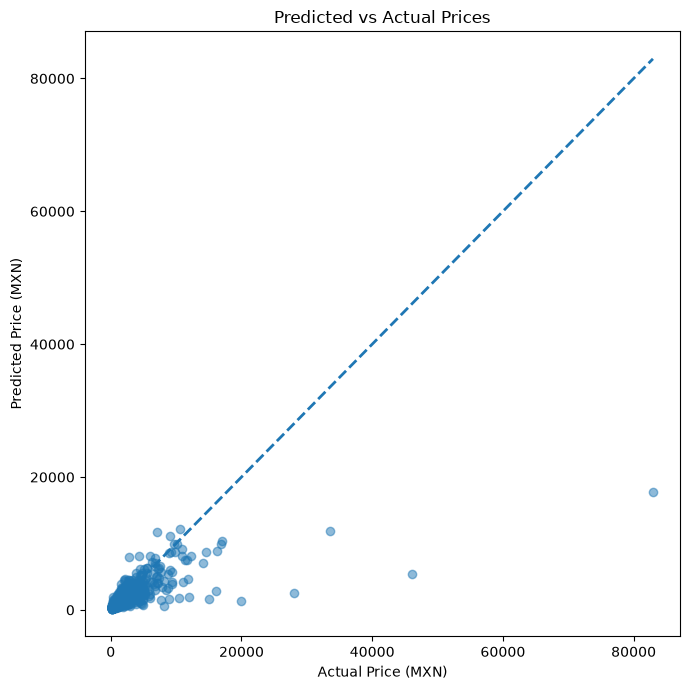

In [24]:
# PREDICTED VS ACTUAL VALUES

# Generate predictions on the test set
y_pred = final_model.predict(X_test_processed)

# Transform predictions back to the original price scale
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

# Create figure
plt.figure(figsize=(7, 7))

# Scatter plot
plt.scatter(
    y_test_real,
    y_pred_real,
    alpha=0.5
)

# Reference line (perfect predictions)
min_value = min(y_test_real.min(), y_pred_real.min())
max_value = max(y_test_real.max(), y_pred_real.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

# Labels
plt.title("Predicted vs Actual Prices")
plt.xlabel("Actual Price (MXN)")
plt.ylabel("Predicted Price (MXN)")

plt.tight_layout()
plt.show()

La gráfica de predicciones frente a valores reales muestra que, para la mayoría de los alojamientos, las predicciones del modelo se concentran cerca de la línea de referencia (*y = x*), lo que indica una buena concordancia entre los precios estimados y los observados. Este comportamiento es consistente con las métricas de desempeño obtenidas previamente y confirma que el modelo captura adecuadamente los patrones presentes en la mayor parte del conjunto de datos.

Sin embargo, también se observan algunos puntos alejados de la diagonal, principalmente correspondientes a alojamientos con precios muy elevados. En estos casos, el modelo tiende a **subestimar** el precio real, como se aprecia en los inmuebles ubicados hacia el extremo derecho de la gráfica. Este comportamiento es habitual en problemas de predicción de precios, donde las propiedades de lujo representan una proporción muy pequeña del conjunto de entrenamiento y, por lo tanto, el modelo dispone de menos ejemplos para aprender correctamente su comportamiento.

Por otra parte, la mayor concentración de observaciones se encuentra en el rango de precios bajos y medios, donde las predicciones presentan una dispersión relativamente reducida alrededor de la línea de referencia. Esto sugiere que el modelo ofrece un desempeño sólido precisamente en el segmento donde se concentra la mayor parte de los anuncios de Airbnb.

En conjunto, la gráfica confirma que el modelo final presenta un buen ajuste para la mayoría de las observaciones, mientras que las mayores discrepancias se concentran en un número reducido de alojamientos con precios excepcionalmente altos. Este comportamiento es coherente con los resultados obtenidos durante la evaluación cuantitativa y explica, en parte, el incremento observado en el RMSE al expresarlo en la escala original de precios.

#### Distribución de los Residuos

A continuación se analizará la distribución de los residuos del modelo, definidos como la diferencia entre el valor real y el valor predicho para cada observación.

En un modelo de regresión con buen ajuste, se espera que los residuos estén centrados alrededor de cero y que su distribución sea aproximadamente simétrica. Esto indica que el modelo no presenta un sesgo sistemático hacia la sobreestimación o subestimación de los valores objetivo. El análisis de esta distribución permitirá identificar posibles desviaciones del comportamiento esperado, como errores sistemáticos, distribuciones asimétricas o la presencia de observaciones con errores excepcionalmente grandes.

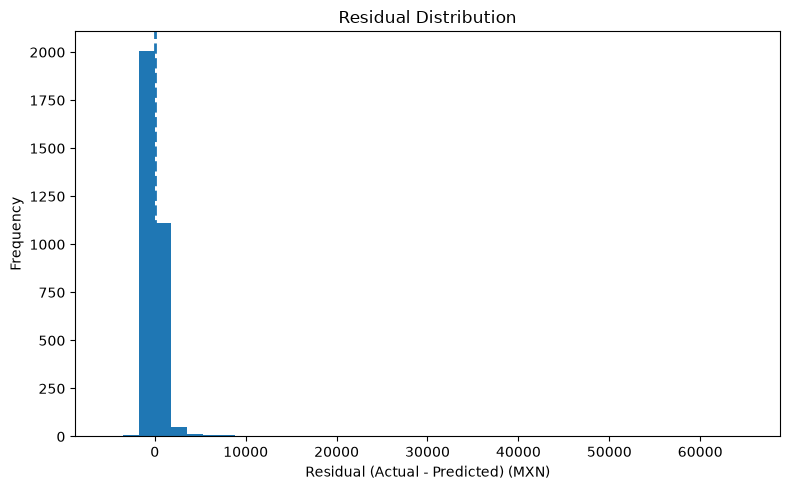

In [25]:
# RESIDUAL DISTRIBUTION

# Compute residuals in the original price scale
residuals = y_test_real - y_pred_real

# Create figure
plt.figure(figsize=(8, 5))

# Histogram of residuals
plt.hist(
    residuals,
    bins=40
)

# Reference line at zero
plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

# Labels
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted) (MXN)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

La distribución de los residuos muestra que la mayor parte de los errores del modelo se concentra alrededor de cero, lo que indica que, para la mayoría de los alojamientos, las predicciones se encuentran relativamente cerca de los valores reales. Esta concentración es consistente con el buen desempeño observado en las métricas de evaluación y sugiere que el modelo no presenta un sesgo sistemático importante hacia la sobreestimación o subestimación.

No obstante, la distribución presenta una ligera asimetría hacia la derecha, evidenciada por una cola positiva más extensa. Esto indica la existencia de un pequeño número de observaciones para las cuales el precio real fue considerablemente mayor que el precio predicho, es decir, el modelo tendió a subestimar algunos alojamientos de precio elevado. simismo, se observan algunos residuos negativos de gran magnitud, aunque son menos frecuentes. Estos corresponden a casos en los que el modelo sobreestimó el precio de determinados alojamientos.

Las mayores discrepancias corresponden principalmente a alojamientos con precios excepcionalmente altos, los cuales representan una proporción muy reducida del conjunto de datos. Debido a que estos listings forman parte del problema de negocio, se decidió conservarlos durante el entrenamiento. La transformación logarítmica aplicada sobre la variable objetivo permitió reducir su influencia sin eliminar información potencialmente relevante.

La distribución de resiudos confirma que los errores más grandes se concentran en este número reducido de propiedades con precios extremos, mientras que la gran mayoría de las observaciones presenta errores considerablemente menores. Este comportamiento es coherente con la naturaleza del mercado de Airbnb y con los resultados obtenidos en las métricas de desempeño y la gráfica de predicciones frente a valores reales.



#### Residuos vs Predicciones

Después de analizar la distribución de los residuos, resulta útil estudiar cómo se comportan en función de las predicciones generadas por el modelo. En un modelo de regresión bien ajustado, los residuos deberían distribuirse aleatoriamente alrededor de cero, sin mostrar patrones claros ni cambios sistemáticos en su dispersión. La presencia de tendencias, formas definidas o variaciones en la amplitud de los residuos puede indicar relaciones no capturadas, sesgos en las predicciones o la existencia de heterocedasticidad.

Esta visualización permitirá evaluar si los errores permanecen estables a lo largo del rango de valores predichos e identificar posibles regiones donde el modelo presenta un desempeño inferior.

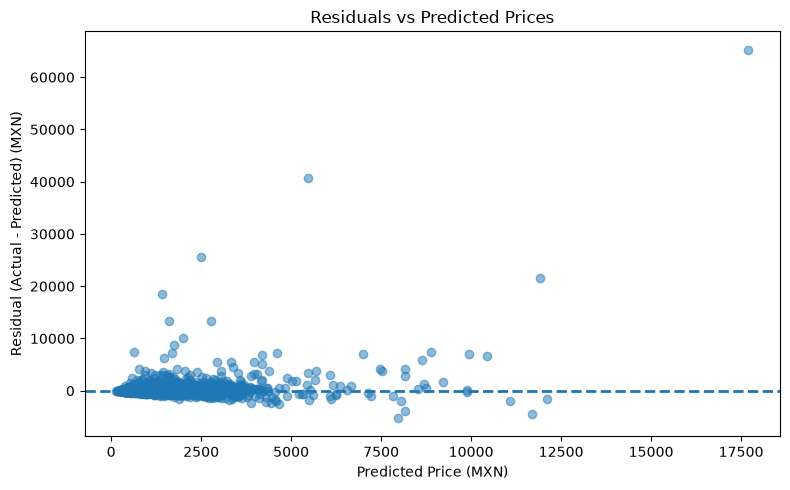

In [26]:
# RESIDUALS VS PREDICTIONS

import matplotlib.pyplot as plt

# Residuals in original price scale
residuals = y_test_real - y_pred_real

# Create figure
plt.figure(figsize=(8, 5))

# Scatter plot
plt.scatter(
    y_pred_real,
    residuals,
    alpha=0.5
)

# Reference line at zero residual
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

# Labels
plt.title("Residuals vs Predicted Prices")
plt.xlabel("Predicted Price (MXN)")
plt.ylabel("Residual (Actual - Predicted) (MXN)")

plt.tight_layout()
plt.show()

La gráfica de residuos frente a predicciones muestra que la mayor parte de los errores se distribuye de forma aleatoria alrededor de la línea horizontal correspondiente a un residuo igual a cero. Esta ausencia de patrones claramente definidos sugiere que el modelo no presenta un sesgo sistemático importante y que, en general, las predicciones son consistentes a lo largo de la mayor parte del rango de precios.

Asimismo, se observa que la mayor concentración de observaciones corresponde a alojamientos con precios predichos bajos y medios, donde los residuos permanecen relativamente cercanos a cero. Esto indica que el modelo ofrece un desempeño estable precisamente en el segmento que concentra la mayor parte de las propiedades del conjunto de datos.

No obstante, conforme aumentan los precios predichos, la dispersión de los residuos también tiende a incrementarse y aparecen algunos errores de gran magnitud, especialmente positivos. Estos casos corresponden a alojamientos cuyo precio real fue considerablemente superior al estimado por el modelo, evidenciando una tendencia a subestimar algunas propiedades de alto valor. También existen algunos residuos negativos importantes, aunque son menos frecuentes.

En conjunto, la gráfica no revela patrones que sugieran una especificación incorrecta del modelo o un sesgo sistemático en las predicciones. Las mayores discrepancias se concentran en un número reducido de alojamientos de precio elevado, un comportamiento esperable dada la menor representación de este tipo de propiedades en el conjunto de entrenamiento y consistente con los análisis realizados en las secciones anteriores.

### Interpretabilidad del Modelo con SHAP

Después de verificar que el modelo presenta un comportamiento consistente y no muestra patrones importantes en sus errores durante el diagnóstico, el siguiente paso consiste en comprender cómo utiliza las variables de entrada para generar sus predicciones. Para ello se empleará **SHAP (SHapley Additive exPlanations)**, una técnica de interpretabilidad basada en la teoría de juegos que permite cuantificar la contribución de cada característica tanto a nivel global como para predicciones individuales.

En primer lugar, se utilizará un **Summary Plot** para identificar las variables que ejercen mayor influencia sobre las predicciones del modelo y analizar la dirección de dicho efecto. Posteriormente, se empleará un **Waterfall Plot** para explicar en detalle una predicción individual, mostrando cómo cada característica contribuye a incrementar o disminuir el precio estimado de un alojamiento específico.

Este análisis complementa las métricas de desempeño y el diagnóstico del modelo, proporcionando una visión más profunda del proceso de decisión aprendido por el algoritmo.

#### Impacto global de las variables en el modelo (SHAP Summary Plot)

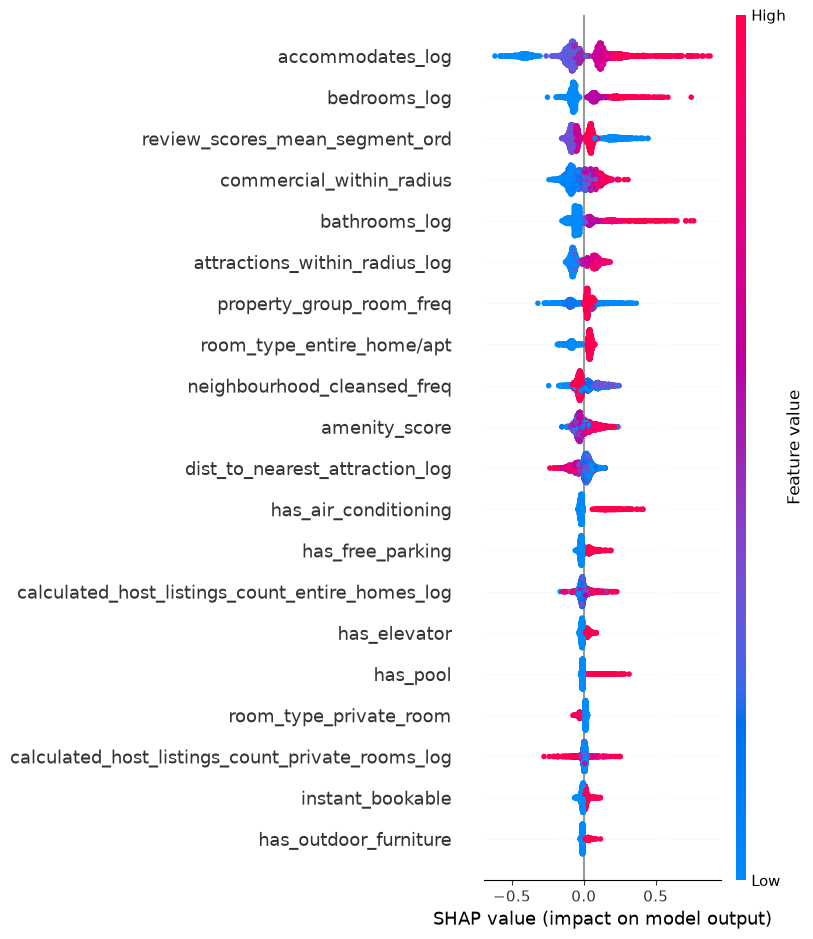

In [27]:
# SHAP SUMMARY PLOT

# Create SHAP explainer
explainer = shap.TreeExplainer(final_model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test_processed)

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_processed,
    max_display=20,
    show=True
)

El **SHAP Summary Plot** proporciona una explicación global del comportamiento del modelo final, mostrando simultáneamente la importancia de cada variable y la dirección con la que influye sobre las predicciones. A diferencia de la importancia de variables basada únicamente en la estructura del modelo, SHAP permite cuantificar la contribución real de cada característica sobre las predicciones individuales, ofreciendo una interpretación más completa del proceso de decisión aprendido por el algoritmo.

En conjunto, el gráfico muestra cómo cada variable afecta las predicciones del modelo y la distribución de esos efectos en todas las observaciones:

- Cada punto representa una observación (una fila del dataset).  
- Eje Y (vertical): lista las variables ordenadas por su importancia global (las más influyentes arriba).  
- Eje X (horizontal): muestra el valor SHAP, que indica el impacto de esa variable en la predicción del modelo.  
  - Valores positivos: la variable contribuye a aumentar la predicción.  
  - Valores negativos: la variable contribuye a disminuir la predicción.  
- Color del punto: representa el valor original del feature.  
  - Rojo (High): valores altos del feature.  
  - Azul (Low): valores bajos del feature.  
- Densidad de puntos: refleja cuántas observaciones tienen valores similares de SHAP; zonas más densas indican mayor frecuencia.  
- Barra de color lateral: sirve como referencia para interpretar el gradiente de valores (de bajo a alto).

Con el objetivo de interpretar el comportamiento del modelo en condiciones similares a las que enfrentará durante su despliegue, este análisis se realizó utilizando el conjunto de prueba (test set). De esta forma, las explicaciones reflejan cómo el modelo toma decisiones sobre datos completamente no vistos durante el entrenamiento y la optimización de hiperparámetros, proporcionando una visión más representativa de su comportamiento en producción.

Los resultados muestran que `accommodates`, `bedrooms` y `bathrooms` constituyen las variables con mayor influencia sobre las predicciones. En los tres casos se observa un patrón consistente: valores elevados de estas características (representados en color rojo) desplazan las predicciones hacia valores positivos de SHAP, incrementando el precio estimado del alojamiento, mientras que valores bajos (color azul) contribuyen a disminuir la predicción. Este comportamiento resulta coherente con la lógica del problema, ya que propiedades con mayor capacidad, más habitaciones y más baños suelen presentar precios superiores.

También destacan variables relacionadas con la calidad y ubicación del alojamiento. Un mayor `review_scores_mean_segment_ord` incrementa las predicciones, indicando que mejores valoraciones de los huéspedes se asocian con precios más elevados. De manera similar, una mayor cantidad de establecimientos comerciales cercanos (`commercial_within_radius`) y un mayor número de atracciones en el entorno (`attractions_within_radius_log`) ejercen un efecto positivo sobre el precio estimado, mientras que una mayor distancia a la atracción más cercana (`dist_to_nearest_attraction_log`) tiende a reducirlo.

El gráfico también confirma la importancia de determinadas características del inmueble. La presencia de aire acondicionado, estacionamiento gratuito, elevador y alberca genera contribuciones positivas en una parte importante de las observaciones, aunque su impacto individual resulta considerablemente menor que el de las variables estructurales del alojamiento.

Un aspecto particularmente interesante corresponde a `amenity_score`. Aunque durante el análisis exploratorio esta variable mostró una correlación relativamente elevada con el precio y fue considerada una de las características potencialmente más relevantes, SHAP indica que su contribución individual es moderada en comparación con variables como la capacidad del alojamiento, el número de habitaciones o los baños. Esto sugiere que gran parte de la información contenida en el puntaje de amenidades ya es capturada indirectamente por otras características del modelo, reduciendo su aporte marginal durante la predicción.

Finalmente, la distribución de los valores SHAP muestra que las variables más importantes presentan una amplia dispersión horizontal, lo que indica que pueden ejercer efectos tanto positivos como negativos dependiendo de las características específicas de cada alojamiento. Este comportamiento evidencia que el modelo no aplica reglas lineales simples, sino que aprende interacciones complejas entre múltiples variables para estimar el precio de cada propiedad.

#### Explicación de predicciones individuales (SHAP Waterfall Plot)

Mientras que el SHAP Summary Plot permitió comprender el comportamiento global del modelo, el siguiente análisis se centrará en explicar predicciones individuales. Para ello se utilizará un SHAP Waterfall Plot, una visualización que descompone una predicción específica mostrando cómo cada característica del alojamiento contribuye a incrementar o disminuir el precio estimado respecto al valor base del modelo.

Con el fin de obtener una visión más completa del comportamiento del modelo, se analizarán dos casos distintos. En primer lugar, se interpretará una observación aleatoria del conjunto de prueba para ilustrar el funcionamiento habitual del modelo. Posteriormente, se estudiará la observación que presentó el mayor error absoluto de predicción, con el objetivo de comprender qué factores pudieron contribuir a esta discrepancia.

RANDOM TEST OBSERVATION
Index: 3092
Actual Price:    $2,595.00 MXN
Predicted Price: $2,385.45 MXN


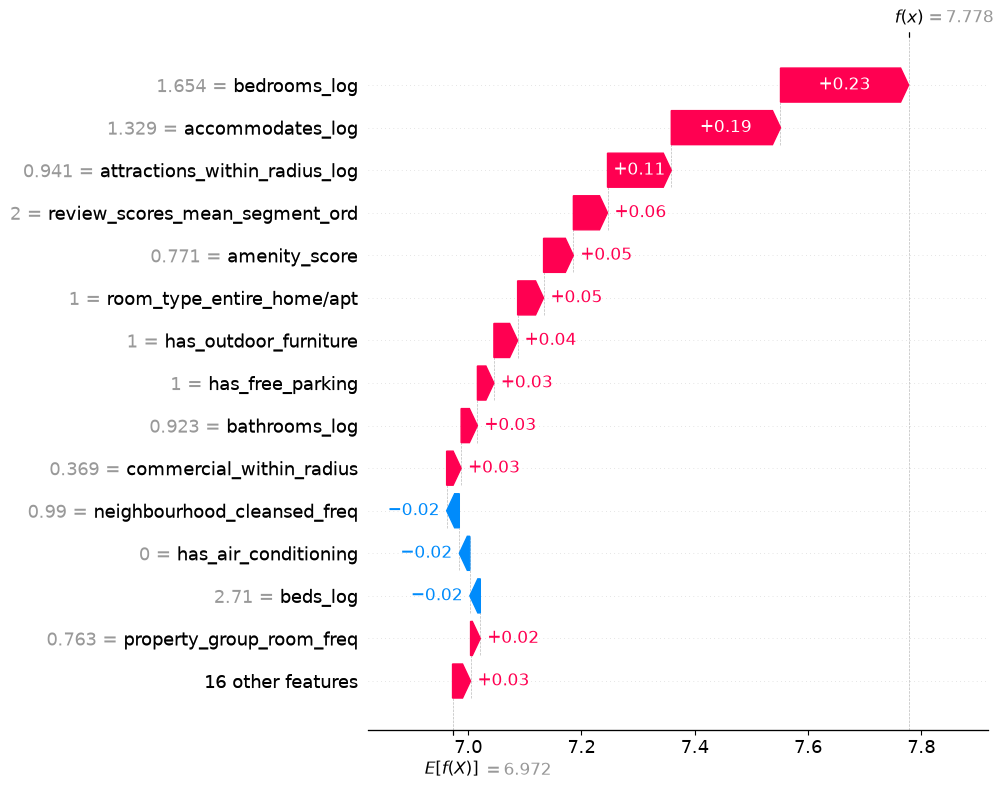

In [28]:
# SHAP WATERFALL PLOT - CASE 1: RANDOM TEST OBSERVATION

# Random observation
np.random.seed(33)
sample_index = np.random.randint(0, len(X_test_processed))

# Display prediction
print("=" * 50)
print("RANDOM TEST OBSERVATION")
print("=" * 50)
print(f"Index: {sample_index}")
print(f"Actual Price:    ${y_test_real.iloc[sample_index]:,.2f} MXN")
print(f"Predicted Price: ${y_pred_real[sample_index]:,.2f} MXN")

# SHAP explanation
shap_explanation = explainer(
    X_test_processed.iloc[[sample_index]]
)

# Waterfall plot
shap.plots.waterfall(
    shap_explanation[0],
    max_display=15
)

En el caso 1 (observación aleatoria) se analiza la observación con índice 3092 del conjunto de prueba. Para este alojamiento, el precio real registrado fue de \$2,595.00 MXN, mientras que el modelo estimó un precio de \$2,385.45 MXN. Esto representa una subestimación de aproximadamente \$209.55 MXN, equivalente a un error cercano al **8%**, lo que indica que el modelo logró una predicción razonablemente precisa para este caso.

El gráfico SHAP Waterfall permite explicar cómo el modelo construyó dicha predicción. La explicación parte de un valor base (*E[f(X)] = 6.972*), que representa la predicción promedio del modelo sobre el conjunto de datos. A partir de este valor, cada característica del alojamiento contribuye positiva o negativamente hasta alcanzar la predicción final (*f(x) = 7.778*, en la escala logarítmica utilizada durante el entrenamiento).

- Eje horizontal: muestra la escala de la predicción del modelo.  
    - El punto de partida es el valor promedio de todas las predicciones: E[f(X)] = 6.972  
    - El punto final es la predicción para esta observación: f(x) = 7.778  
- Bloques rojos y azules: representan el impacto individual de cada variable.  
    - Rojo (+): aumenta la predicción (contribución positiva). 
    - Azul (−): disminuye la predicción (contribución negativa).  
    - El tamaño del bloque indica la magnitud del impacto  
- Valores a la izquierda: muestran el valor real del feature para esa observación.
- Flechas: indican la dirección del cambio acumulativo desde el valor promedio hasta la predicción final.  
- 16 other features: se agrupan las variables con impacto menor, para simplificar la visualización.

En este caso, las variables que más incrementaron la predicción fueron `bedrooms`, `accommodates` y `attractions_within_radius`, indicando que el elevado número de habitaciones, la capacidad del alojamiento y la proximidad a múltiples atracciones turísticas fueron los factores que mayor peso tuvieron para estimar un precio superior al promedio. Este resultado es consistente con el análisis global obtenido mediante el SHAP Summary Plot, donde estas mismas variables aparecieron entre las más influyentes del modelo.

También contribuyeron positivamente características como `review_scores_mean_segment_ord`, un valor de `amenity_score` relativamente alto, el hecho de tratarse de una vivienda completa (`room_type_entire_home/apt`) y la disponibilidad de amenidades específicas como estacionamiento gratuito y mobiliario exterior. Aunque cada una aporta una contribución individual menor, en conjunto incrementan de forma apreciable el precio estimado.

Por otro lado, algunas variables redujeron ligeramente la predicción. Entre ellas destacan la ausencia de aire acondicionado (`has_air_conditioning = 0`), la alcaldía donde se ubica el alojamiento (`neighbourhood_cleansed_freq`) y el número de camas (`beds_log`), aunque su impacto negativo fue considerablemente menor que las contribuciones positivas de las variables principales.

Este ejemplo muestra cómo el modelo no basa su decisión en una única característica, sino que combina la información proveniente de múltiples variables para construir la predicción final. La diferencia relativamente pequeña entre el precio real y el estimado evidencia que el modelo fue capaz de capturar adecuadamente los factores que determinan el valor de este alojamiento, proporcionando una explicación coherente y consistente con el comportamiento observado durante la evaluación del modelo.

LARGEST PREDICTION ERROR
Index: 612
Actual Price:    $82,955.00 MXN
Predicted Price: $17,703.00 MXN
Absolute Error:  $65,252.00 MXN


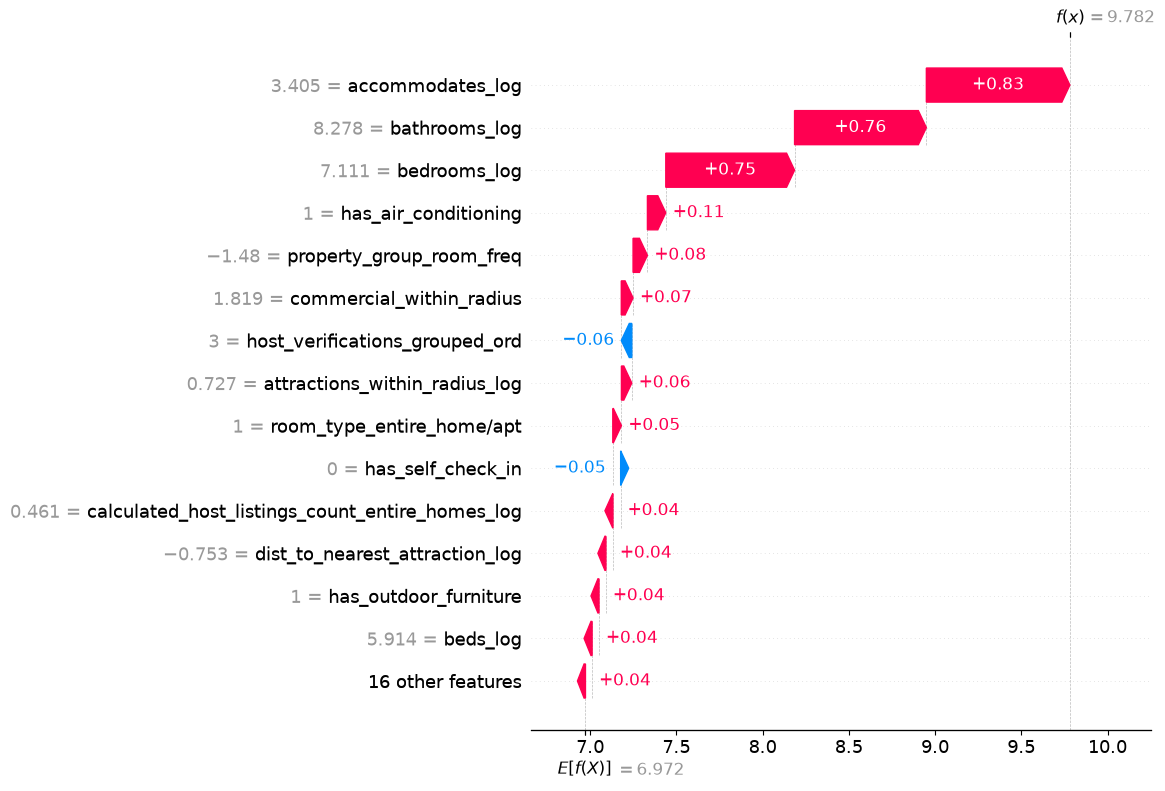

In [29]:
# SHAP WATERFALL PLOT - CASE 2: LARGEST PREDICTION ERROR

# Largest absolute prediction error
largest_error_index = np.argmax(
    np.abs(y_test_real.values - y_pred_real)
)

print("=" * 50)
print("LARGEST PREDICTION ERROR")
print("=" * 50)
print(f"Index: {largest_error_index}")
print(f"Actual Price:    ${y_test_real.iloc[largest_error_index]:,.2f} MXN")
print(f"Predicted Price: ${y_pred_real[largest_error_index]:,.2f} MXN")
print(
    f"Absolute Error:  "
    f"${abs(y_test_real.iloc[largest_error_index]-y_pred_real[largest_error_index]):,.2f} MXN"
)

# SHAP explanation
largest_error_explanation = explainer(
    X_test_processed.iloc[[largest_error_index]]
)

# Waterfall plot
shap.plots.waterfall(
    largest_error_explanation[0],
    max_display=15
)

En este segundo caso se analiza la observación que produjo el mayor error absoluto sobre el conjunto de prueba. Para este alojamiento, el precio real fue de \$82,955.00 MXN, mientras que el modelo estimó un precio de \$17,703.00 MXN, generando un error absoluto de \$65,252.00 MXN. Este resultado corresponde a uno de los alojamientos más costosos del conjunto de datos y representa un caso claramente atípico respecto a la distribución general de precios.

A pesar de la magnitud del error, el SHAP Waterfall Plot muestra que el modelo identificó correctamente la mayoría de las características asociadas con un alojamiento de alto valor. Partiendo del valor base (*E[f(X)] = 6.972*), prácticamente todas las variables más relevantes contribuyen positivamente hasta alcanzar una predicción final de *f(x) = 9.782* (escala logarítmica), muy superior al promedio del conjunto de datos.

Las mayores contribuciones provienen de `accommodates`, `bathrooms` y `bedrooms`, que incrementan considerablemente la predicción. Esto indica que el modelo reconoce que se trata de una propiedad excepcionalmente amplia y con características físicas muy superiores a las de un alojamiento promedio. Asimismo, variables como la presencia de aire acondicionado, la cercanía a zonas comerciales, el tipo de propiedad (Entire Home/Apt), la proximidad a atracciones y otras amenidades también incrementan el precio estimado, reforzando la percepción de que el inmueble posee atributos propios de un alojamiento premium.

Por el contrario, únicamente unas pocas variables reducen ligeramente la predicción, como `host_verifications_grouped_ord` y la ausencia de `self check-in`, aunque su efecto resulta pequeño frente a las fuertes contribuciones positivas del resto de las características.

El aspecto más relevante de este análisis es que el error no parece originarse por una interpretación incorrecta de las variables, sino por la escasa representación de alojamientos extremadamente costosos dentro del conjunto de entrenamiento. Aunque el modelo identifica correctamente que la propiedad debe tener un precio muy superior al promedio, termina subestimando el valor real debido a que dispone de pocas referencias similares durante el proceso de aprendizaje. Este comportamiento es consistente con los análisis previos del diagnóstico, donde se observó que los mayores errores se concentraban precisamente en el segmento de precios más elevados.

En conjunto, este ejemplo demuestra que el modelo mantiene una lógica de decisión coherente incluso en los casos donde presenta sus mayores errores. La explicación proporcionada por SHAP confirma que las variables relevantes fueron correctamente identificadas y ponderadas. Sin embargo, la limitada cantidad de ejemplos pertenecientes al extremo superior de la distribución de precios restringe la capacidad del modelo para extrapolar con precisión este tipo de alojamientos excepcionales. Esta limitación es inherente al conjunto de datos y constituye una oportunidad de mejora para futuras versiones del modelo mediante la incorporación de un mayor número de propiedades de lujo o estrategias específicas para el tratamiento de valores extremos.

## 11. Guardado Final de Artefactos

In [30]:
# SAVE PRODUCTION ARTIFACTS

# Create production directory if it does not exist
production_dir = Path("../models/production")
production_dir.mkdir(parents=True, exist_ok=True)

# Save preprocessing pipeline
joblib.dump(
    preprocessing_pipeline,
    production_dir / "preprocess_pipeline.joblib"
)

# Save final trained model
joblib.dump(
    final_model,
    production_dir / "final_model.joblib"
)

# Save SHAP explainer
joblib.dump(
    explainer,
    production_dir / "shap_explainer.joblib"
)

# Save feature list
feature_list = list(X_train_final.columns)

with open(
    production_dir / "feature_list.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        feature_list,
        f,
        indent=4
    )

# Save evaluation metrics
metrics = {
    "train_r2": final_model_eval_results["train_r2"],
    "train_rmse": final_model_eval_results["train_rmse"],
    "train_mae": final_model_eval_results["train_mae"],
    "evaluation_r2": final_model_eval_results["eval_r2"],
    "evaluation_rmse": final_model_eval_results["eval_rmse"],
    "evaluation_mae": final_model_eval_results["eval_mae"],
    "evaluation_rmse_real": final_model_eval_results["eval_rmse_real"],
    "evaluation_mae_real": final_model_eval_results["eval_mae_real"],
    "cv_mean_r2": final_model_cv_results["mean"],
    "cv_std_r2": final_model_cv_results["std"]
}


with open(
    production_dir / "metrics.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metrics,
        f,
        indent=4
    )

# Save model configuration
config = {
    "model_name": "XGBoost Regressor",
    "model_version": "1.0.0",
    "target": "price",
    "target_transformation": "log1p",
    "algorithm": "XGBoost",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open(
    production_dir / "config.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        config,
        f,
        indent=4
    )

# Summary
print("=" * 60)
print("PRODUCTION ARTIFACTS SAVED")
print("=" * 60)

artifacts_summary = pd.DataFrame({
    "Artifact": [
        "preprocess_pipeline.joblib",
        "final_model.joblib",
        "shap_explainer.joblib",
        "feature_list.json",
        "metrics.json",
        "config.json"
    ],
    "Description": [
        "Preprocessing pipeline",
        "Final trained XGBoost model",
        "SHAP TreeExplainer",
        "Ordered feature names",
        "Final evaluation metrics",
        "Model configuration"
    ]
})

print(artifacts_summary)

PRODUCTION ARTIFACTS SAVED
                     Artifact                  Description
0  preprocess_pipeline.joblib       Preprocessing pipeline
1          final_model.joblib  Final trained XGBoost model
2       shap_explainer.joblib           SHAP TreeExplainer
3           feature_list.json        Ordered feature names
4                metrics.json     Final evaluation metrics
5                 config.json          Model configuration


### Conclusiones y próximos pasos

A lo largo de este notebook se entrenaron, evaluaron e interpretaron distintos modelos de aprendizaje automático para la predicción del precio de alojamientos Airbnb en la Ciudad de México:

- La Regresión Lineal permitió establecer una línea base sólida y proporcionó una primera aproximación al problema. 
- Posteriormente, Random Forest y XGBoost demostraron una capacidad significativamente mayor para capturar las relaciones no lineales presentes en los datos, obteniendo mejoras sustanciales en las métricas de desempeño.
- Tras la optimización de hiperparámetros mediante Randomized Search Cross-Validation, XGBoost fue seleccionado como modelo final al alcanzar el mejor equilibrio entre capacidad predictiva, estabilidad y generalización. Sobre el conjunto de prueba, el modelo obtuvo un R² de 0.7831, un RMSE de \$1,728.12 MXN y un MAE de \$411.84 MXN, manteniendo un desempeño consistente durante la validación cruzada.

A pesar de estos buenos resultados, el diagnóstico reveló que el modelo experimenta errores de predicción significativos en un grupo muy reducido de alojamientos. Tras verificar los datos, se confirmó que corresponden a propiedades legítimas de gama alta o ultra lujo que manejan dinámicas de precio muy distintas al resto del mercado. Dado que el objetivo del proyecto fue conservar estos registros para representar fielmente todo el ecosistema de Airbnb en la Ciudad de México, el modelo actual tiende a subestimar sus precios debido al peso del mercado masivo. 

Para escenarios donde se requiera priorizar el rendimiento estricto en estos segmentos extremos, una alternativa de mejora consistiría en segmentar el problema mediante el entrenamiento de dos modelos especializados de forma separada (uno para el mercado estándar y otro exclusivo para el segmento premium). No obstante, para los fines de este proyecto, el modelo actual optimizado ofrece el balance ideal de generalización en un único pipeline.

Además de evaluar su rendimiento, se realizó un análisis de interpretabilidad utilizando SHAP, permitiendo comprender tanto el comportamiento global del modelo como las razones detrás de predicciones individuales. Este análisis confirmó que variables como la capacidad del alojamiento, el número de habitaciones, los baños, la ubicación y las amenidades constituyen los principales determinantes del precio estimado, proporcionando evidencia adicional de que el modelo aprende relaciones coherentes con el dominio del problema.

Finalmente, se generaron y almacenaron todos los artefactos necesarios para reutilizar el modelo en producción, incluyendo el pipeline de preprocesamiento, el modelo entrenado, la lista de variables y la configuración del modelo. Esto garantiza que las mismas transformaciones aplicadas durante el entrenamiento puedan reproducirse durante la inferencia sobre nuevos datos. Con el desarrollo del modelo final concluye la fase de modelado de este proyecto.

En el siguiente notebook se abordará la etapa de despliegue, donde el modelo será integrado en una aplicación completa utilizando FastAPI como servicio de inferencia y Streamlit como interfaz de usuario. Durante esta etapa se cargarán los artefactos generados, se implementará el flujo completo de predicción para nuevos alojamientos y se construirá una interfaz interactiva que permitirá estimar el precio de propiedades Airbnb en tiempo real.

Con ello, el proyecto evolucionará desde un análisis de ciencia de datos hacia una solución de aprendizaje automático lista para ser utilizada por usuarios finales, siguiendo un flujo de trabajo similar al empleado en aplicaciones reales de Machine Learning.